# Uncorrelated-Case (Q) Power Spectrum Correction

Spun off from `DM_benchmark_nico_pypower_.ipynb`: **only the uncorrelated case**
(section 3.2 of the derivation notes) and the Setup section. 

**Goal.** Perturb particle positions $\mathbf{x}_i' = \mathbf{x}_i + \nabla\phi(\mathbf{x}_i)$,
with $\phi$ drawn from a power spectrum $Q(k)$ solved so that the perturbed point set's
$P(k)$ matches a reference/target $P(k)$.

Our Fourier convention (periodic box):
$$
\Delta_\mathbf{k} = \frac{1}{V}\int_V \Delta(\mathbf{x})e^{-i\mathbf{k}\cdot\mathbf{x}}\,d^3x,\qquad
\Delta(\mathbf{x}) = \sum_\mathbf{k}\Delta_\mathbf{k}e^{i\mathbf{k}\cdot\mathbf{x}},\qquad
\langle\Delta_\mathbf{k}\Delta_{\mathbf{k}'}^*\rangle = \delta_D(\mathbf{k},\mathbf{k}')\frac{P(k)}{V}.
$$


**Two pypower-speed choices kept throughout:** `interlacing=2` stays on always (turning it
off lets $P(k)$ upturn spuriously near $k_\mathrm{Nyquist}$ — aliasing isn't suppressed
without it); and the separate `CatalogMesh`/`to_mesh()` pass the combined notebook used for
density-field diagnostics is dropped, since the Q-only pipeline never needs the delta fields
themselves, only their $P(k)$.


## Imports


In [1]:
import os, time, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.interpolate import interp1d
from matplotlib.colors import LogNorm

import pyfftw
from numba import njit, prange

import psutil
from psutil._common import bytes2human

# Pylians -- only readgadget is needed (snapshot I/O); MAS_library / Pk_library /
# density_field_library are NOT imported: the Q-only pipeline measures P(k) with
# pypower and builds phi(x) by hand (white noise + pyfftw), no Pylians density
# fields or Pylians Gaussian-field generator needed.
import readgadget

# pypower
from pypower import CatalogFFTPower, CatalogMesh
import PolyBin3D as pb

plt.style.use("dark_background")

# numpy >=2.x renamed trapz -> trapezoid; keep this notebook portable across
# whatever numpy version is on the cluster vs locally.
_trapz = getattr(np, "trapz", None) or np.trapezoid

format_float = lambda z: "%ip%i" % (int(z // 1), int(z % 1 * 10))

def sci_notation(number, sig_fig=2):
    ret_string = "{0:.{1:d}e}".format(number, sig_fig)
    a, b = ret_string.split("e")
    b = int(b)
    return a + r"$\times 10^{%i}$" % b

print("Numpy version:", np.__version__)
print("Total memory:", bytes2human(psutil.virtual_memory()[0]))
print("Number of CPUs:", os.cpu_count())

figroot = os.path.join("Figures", "Pypower_Qcase")
os.makedirs(figroot, exist_ok=True)
os.makedirs("precomps", exist_ok=True)


--------------------------------------------------------------------------

  Local host:   a011
  Local device: mlx5_0
--------------------------------------------------------------------------
[a011.anvil.rcac.purdue.edu:1793329] common_ucx.c:362  Warning: UCX is unable to handle VM_UNMAP event. This may cause performance degradation or data corruption. Pls try adding --mca opal_common_ucx_opal_mem_hooks 1 to mpirun/oshrun command line to resolve this issue.


Numpy version: 1.23.5
Total memory: 251.5G
Number of CPUs: 128


## Compute resources, and making the pypower calls faster

Two independent speed levers, worth separating clearly:

1. **`pyfftw` threads** (used below for the $\phi(\mathbf{x})$/gradient FFTs): genuinely
   OpenMP-threaded, scales with cores on one node. We pick the thread count from
   `detect_compute_resources()` instead of a hardcoded `N_CPU = 16`.
2. **`pypower`'s own FFT** (via `pmesh`/`pfft` inside `CatalogFFTPower`): `pfft` is linked
   against `libmpi`, **not** threaded FFTW, so `OMP_NUM_THREADS` does nothing for it.
   Real parallelism only comes from running under multiple **MPI ranks**
   (`mpirun -n N python ...`). A single, normally-launched Jupyter kernel is one MPI rank
   (`COMM_WORLD` size 1) no matter how many cores the node has. `run_pypower_via_mpirun()`
   below is a best-effort helper for that case: it ships the measurement out to a small
   standalone script under `mpirun`, since a running single-rank process can't retroactively
   turn itself into N ranks.

We also default to `dtype='f4'` (single precision mesh) in `measure_power_pypower` — halves
FFT/mesh memory and compute versus the `'f8'` default, at negligible cost in $P(k)$ accuracy
for this use case.


In [2]:
def detect_compute_resources():
    info = {'cpu_count': os.cpu_count()}
    for var in ("SLURM_CPUS_PER_TASK", "SLURM_NTASKS", "SLURM_JOB_CPUS_PER_NODE", "SLURM_CPUS_ON_NODE"):
        if var in os.environ:
            info[var] = os.environ[var]
    try:
        from mpi4py import MPI
        info['mpi4py_available'] = True
        info['mpi_world_size'] = MPI.COMM_WORLD.Get_size()
        info['mpi_rank'] = MPI.COMM_WORLD.Get_rank()
    except ImportError:
        info['mpi4py_available'] = False
        info['mpi_world_size'] = 1
    return info

resources = detect_compute_resources()
print(resources)
if resources['mpi_world_size'] == 1:
    print("Running as a single MPI rank: pypower's own FFT will NOT be parallel "
          "(see markdown above). pyfftw calls below will still use "
          "resources['cpu_count'] OpenMP threads.")


{'cpu_count': 128, 'SLURM_CPUS_PER_TASK': '35', 'SLURM_NTASKS': '1', 'SLURM_JOB_CPUS_PER_NODE': '35', 'SLURM_CPUS_ON_NODE': '35', 'mpi4py_available': True, 'mpi_world_size': 1, 'mpi_rank': 0}
Running as a single MPI rank: pypower's own FFT will NOT be parallel (see markdown above). pyfftw calls below will still use resources['cpu_count'] OpenMP threads.


In [3]:
def run_pypower_via_mpirun(positions, BoxSize, grid, kedges, n_ranks=None,
                            resampler='cic', interlacing=2, dtype='f4',
                            work_dir='precomps_mpi', tag='tmp'):
    '''
    Best-effort cluster helper: launches the P(k) measurement in a *separate*
    `mpirun -n n_ranks python ...` subprocess so pmesh/pfft actually gets multiple
    MPI ranks (this notebook's own kernel process cannot retroactively become
    multi-rank). Requires mpi4py + an MPI-enabled pypower/pmesh install on PATH.

    Not exercised in this notebook's own validation run below (no real mpirun/
    cluster pypower install available where this notebook was authored) --
    benchmark against `measure_power_pypower` on your cluster before relying on it.
    '''
    import subprocess, textwrap
    os.makedirs(work_dir, exist_ok=True)
    if n_ranks is None:
        n_ranks = detect_compute_resources()['cpu_count'] or 1

    pos_path = os.path.join(work_dir, f'positions_{tag}.npy')
    kedges_path = os.path.join(work_dir, f'kedges_{tag}.npy')
    out_k_path = os.path.join(work_dir, f'k_{tag}.npy')
    out_pk_path = os.path.join(work_dir, f'pk_{tag}.npy')
    np.save(pos_path, positions)
    np.save(kedges_path, kedges)

    script = textwrap.dedent(f'''
        import numpy as np
        from pypower import CatalogFFTPower
        positions = np.load("{pos_path}")
        kedges = np.load("{kedges_path}")
        result = CatalogFFTPower(data_positions1=positions, boxsize={BoxSize}, nmesh={grid},
                                  resampler="{resampler}", edges=kedges, ells=(0,),
                                  interlacing={interlacing}, position_type='pos', dtype="{dtype}")
        poles = result.poles
        k, Pk = poles(ell=0, return_k=True, complex=False)
        if poles.mpicomm.rank == 0:
            np.save("{out_k_path}", k)
            np.save("{out_pk_path}", Pk)
        ''')
    script_path = os.path.join(work_dir, f'worker_{tag}.py')
    with open(script_path, 'w') as f:
        f.write(script)

    cmd = ["mpirun", "-n", str(n_ranks), sys.executable, script_path]
    print("Launching:", " ".join(cmd))
    subprocess.run(cmd, check=True)

    k, Pk = np.load(out_k_path), np.load(out_pk_path)
    return k[~np.isnan(k)], Pk[~np.isnan(Pk)]


## Functions for the displacement field (numba + pyfftw, no Pylians)


In [4]:
@njit
def trilinear_interp_numba(data, points, x_coords, y_coords, z_coords):
    '''Custom Periodic trilinear interpolation on a regular 3D grid.'''
    nx, ny, nz = data.shape
    num_points = points.shape[0]
    interpolated_values = np.empty(num_points, dtype=data.dtype)
    dx_inv = 1.0 / (x_coords[1] - x_coords[0])
    dy_inv = 1.0 / (y_coords[1] - y_coords[0])
    dz_inv = 1.0 / (z_coords[1] - z_coords[0])
    for i in prange(num_points):
        x_query, y_query, z_query = points[i, :]
        x0_idx = np.searchsorted(x_coords, x_query, side="left") - 1
        y0_idx = np.searchsorted(y_coords, y_query, side="left") - 1
        z0_idx = np.searchsorted(z_coords, z_query, side="left") - 1
        x0_idx, y0_idx, z0_idx = x0_idx % nx, y0_idx % ny, z0_idx % nz
        x1_idx, y1_idx, z1_idx = (x0_idx + 1) % nx, (y0_idx + 1) % ny, (z0_idx + 1) % nz
        x0, y0, z0 = x_coords[x0_idx], y_coords[y0_idx], z_coords[z0_idx]
        xd = (x_query - x0) * dx_inv
        yd = (y_query - y0) * dy_inv
        zd = (z_query - z0) * dz_inv
        c000 = data[x0_idx, y0_idx, z0_idx]; c100 = data[x1_idx, y0_idx, z0_idx]
        c010 = data[x0_idx, y1_idx, z0_idx]; c001 = data[x0_idx, y0_idx, z1_idx]
        c110 = data[x1_idx, y1_idx, z0_idx]; c101 = data[x1_idx, y0_idx, z1_idx]
        c011 = data[x0_idx, y1_idx, z1_idx]; c111 = data[x1_idx, y1_idx, z1_idx]
        interpolated_values[i] = (
            c000*(1-xd)*(1-yd)*(1-zd) + c100*xd*(1-yd)*(1-zd) +
            c010*(1-xd)*yd*(1-zd) + c001*(1-xd)*(1-yd)*zd +
            c110*xd*yd*(1-zd) + c101*xd*(1-yd)*zd +
            c011*(1-xd)*yd*zd + c111*xd*yd*zd
        )
    return interpolated_values


@njit
def displace_positions_interp(positions, new_positions, grad_x, grad_y, grad_z,
                                x_c, y_c, z_c, max_length, threshold=None):
    nabla_x = trilinear_interp_numba(grad_x, positions, x_c, y_c, z_c)
    nabla_y = trilinear_interp_numba(grad_y, positions, x_c, y_c, z_c)
    nabla_z = trilinear_interp_numba(grad_z, positions, x_c, y_c, z_c)
    if threshold is not None:
        for i in prange(nabla_x.shape[0]):
            mag = np.sqrt(nabla_x[i]**2 + nabla_y[i]**2 + nabla_z[i]**2)
            if mag > threshold:
                scale = threshold / mag
                nabla_x[i] *= scale
                nabla_y[i] *= scale
                nabla_z[i] *= scale
    new_positions[:, 0] = np.mod(positions[:, 0] + nabla_x, max_length)
    new_positions[:, 1] = np.mod(positions[:, 1] + nabla_y, max_length)
    new_positions[:, 2] = np.mod(positions[:, 2] + nabla_z, max_length)
    return new_positions, nabla_x, nabla_y, nabla_z


def fourier_shells_k(res, box_size, fshift=True):
    scale = 2*np.pi*res/box_size
    if fshift:
        k_x = np.array(scale*np.fft.fftshift(np.fft.fftfreq(res)), dtype='float32')
    else:
        k_x = np.array(scale*np.fft.fftfreq(res), dtype='float32')
    k_y, k_z = k_x.copy(), k_x.copy()
    kx, ky, kz = np.meshgrid(k_x, k_y, k_z, indexing='ij')
    k_radius_grid = np.sqrt(kx**2 + ky**2 + kz**2)
    return k_x, k_y, k_z, k_radius_grid


@njit
def fill_fourier_grid(weights_grid, k3D_radius, k_bins, weights1D, zero_above_kmax=True):
    '''
    Interpolate weights1D(k_bins) onto the 3D |k| grid.

    `zero_above_kmax` controls what happens above k_bins[-1] (the highest k we
    actually solved Q at): by default (True, matching prior behaviour) those
    grid points get zero weight rather than an extrapolated value -- since
    Q(k) was never solved out there, anything else would be made up. Flagged
    explicitly here (rather than an implicit `extra_right=0.`) and returns a
    diagnostic count so the truncated fraction of k-space is visible.
    '''
    kmax = k_bins[-1]
    n_zeroed = 0
    for ix in prange(k3D_radius.shape[0]):
        for iy in prange(k3D_radius.shape[1]):
            for iz in prange(k3D_radius.shape[2]):
                k_val = k3D_radius[ix, iy, iz]
                if k_val > kmax:
                    if zero_above_kmax:
                        weights_grid[ix, iy, iz] = 0.0
                        n_zeroed += 1
                    else:
                        weights_grid[ix, iy, iz] = weights1D[-1]
                else:
                    weights_grid[ix, iy, iz] = np.interp(k_val, k_bins, weights1D)
    return weights_grid, n_zeroed


In [5]:
def compute_density_slice_2d(positions, BoxSize, grid,
                               x_min, x_max, y_min, y_max, z_min, z_max):
    '''
    2D CIC projected density (1+delta) on the XY plane, averaged over
    z in [z_min, z_max]. No Pylians, no pypower.
    Returns array of shape (nx, ny) in 1+delta units.
    '''
    cell = BoxSize / grid
    nx = max(1, int(round((x_max - x_min) / cell)))
    ny = max(1, int(round((y_max - y_min) / cell)))

    mask = ((positions[:, 0] >= x_min) & (positions[:, 0] < x_max) &
            (positions[:, 1] >= y_min) & (positions[:, 1] < y_max) &
            (positions[:, 2] >= z_min) & (positions[:, 2] < z_max))
    pos = positions[mask]

    xc = (pos[:, 0] - x_min) / cell
    yc = (pos[:, 1] - y_min) / cell
    i0 = np.floor(xc).astype(int) % nx
    j0 = np.floor(yc).astype(int) % ny
    dx = xc - np.floor(xc)
    dy = yc - np.floor(yc)

    rho = np.zeros((nx, ny), dtype='f4')
    for di in (0, 1):
        for dj in (0, 1):
            wx = dx if di else 1.0 - dx
            wy = dy if dj else 1.0 - dy
            np.add.at(rho, ((i0 + di) % nx, (j0 + dj) % ny), wx * wy)

    nbar = rho.mean()
    return rho / nbar if nbar > 0 else rho + 1.0


def plot_density_slices(pos_list, labels, BoxSize, grid,
                         x_min, x_max, y_min, y_max, z_min, z_max,
                         scale='log', colmap='hot', dmin=0.1, dmax=100,
                         smooth_sigma=None, figroot=None,
                         fname='dfield_slices.pdf'):
    '''
    One-row, N-column density-field slice plot with a single shared colorbar.
    No Pylians. Default: compare initial PM to corrected positions.

    Parameters
    ----------
    pos_list     : list of (N,3) float32 arrays, one per panel
    labels       : list of str panel titles
    BoxSize,grid : box size and mesh resolution (same as power-spectrum calls)
    x/y/z_min/max: spatial extent; z range sets the slab depth averaged over
    scale        : 'log' or 'linear'
    dmin, dmax   : clipping limits on 1+delta
    smooth_sigma : optional Gaussian smoothing in grid cells (None = off)
    figroot      : directory to save PDF; None = don't save
    '''
    from scipy.ndimage import gaussian_filter

    n = len(pos_list)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5.5),
                              sharey=True, constrained_layout=True)
    if n == 1:
        axes = [axes]

    fields = []
    for pos in pos_list:
        d = compute_density_slice_2d(pos, BoxSize, grid,
                                      x_min, x_max, y_min, y_max, z_min, z_max)
        if smooth_sigma is not None:
            d = gaussian_filter(d, sigma=smooth_sigma)
        fields.append(np.clip(d, dmin, dmax))

    vmin = min(f.min() for f in fields)
    vmax = max(f.max() for f in fields)
    norm = LogNorm(vmin=vmin, vmax=vmax) if scale == 'log' else \
           plt.Normalize(vmin=vmin, vmax=vmax)

    extent = [x_min, x_max, y_min, y_max]
    im = None
    for ax, field, label in zip(axes, fields, labels):
        im = ax.imshow(field.T, origin='lower', extent=extent,
                        cmap=colmap, norm=norm,
                        interpolation='sinc', aspect='equal')
        ax.set_title(label, fontsize=14)
        ax.set_xlabel(r'$x\ [h^{-1}\mathrm{Mpc}]$', fontsize=14)
    axes[0].set_ylabel(r'$y\ [h^{-1}\mathrm{Mpc}]$', fontsize=14)

    cbar = fig.colorbar(im, ax=axes, fraction=0.05, pad=0.02, aspect=30)
    cbar.set_label(r'$1+\delta$', fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    fig.suptitle(r'$z \in [%.1f,\,%.1f]\ h^{-1}\mathrm{Mpc}$' % (z_min, z_max),
                  fontsize=16)

    if figroot is not None:
        os.makedirs(figroot, exist_ok=True)
        plt.savefig(os.path.join(figroot, fname), bbox_inches='tight')
    return fig, axes

# 1) Setup and load data

We perturb an L-PICOLA (fast/approximate) snapshot, with the reference/target being a full
N-body (Quijote) snapshot at the same seed. Adjust the cosmology, paths and grid below for
your run.


In [6]:
params = ["Omega_m", "Omega_b", "h", "n_s", "sigma_8"]
cosmology = {"sigma_8": 0.834, "n_s": 0.9624, "h": 0.671, "Omega_b": 0.049, "Omega_m": 0.3175}


In [7]:
# SETUP PARAMS
grid = 256
BoxSize = 1000.0  # Mpc/h, overwritten below from the snapshot header
MAS = 'CIC'

redshift = 0.5
a = 1 / (1 + redshift)
z_str = format_float(redshift)
seed = 1

# SNAPSHOT LOCATIONS -- edit these for your run
nbody = "/anvil/scratch/x-nchartier/snapshots/quijote_fid_z%s_seed%i/snapdir_003/snap_003" % (z_str, seed)
app = "/anvil/scratch/x-nchartier/snapshots/cola_fid_z%s_seed%i/Cola1_20steps_mesh512_nLPTpos0p5_z0p500" % (z_str, seed)
ptype = [1]  # [1] CDM, [2] neutrinos, [1, 2] CDM+neutrinos

basedir = "/home/x-nchartier/PkCorr/Figures"
os.makedirs(os.path.join(basedir, "LPICOLA"), exist_ok=True)


In [8]:
# Reference / target (N-body)
header = readgadget.header(nbody)
BoxSize = header.boxsize / 1e3  # Mpc/h
print("BoxSize = %.1f Mpc/h" % BoxSize)
Omega_m, Omega_l, h = header.omega_m, header.omega_l, header.hubble
pos_nb = readgadget.read_block(nbody, "POS ", ptype) / 1e3  # Mpc/h

# Fast/approximate generator to correct (L-PICOLA)
header_pm = readgadget.header(app)
pos_pm = readgadget.read_block(app, "POS ", ptype) / 1e3  # Mpc/h
print("pos_pm shape:", pos_pm.shape, " pos_nb shape:", pos_nb.shape)


BoxSize = 1000.0 Mpc/h
pos_pm shape: (134217728, 3)  pos_nb shape: (134217728, 3)


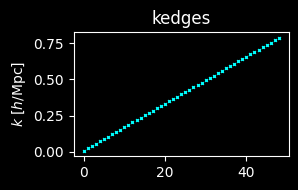

In [9]:
kNyquist = np.pi * grid / BoxSize
kFund = 2 * np.pi / BoxSize

num_bins = 50
interlacing_order = 2  # kept on always -- see markdown above
# kedges[-1] dropped: pypower leaves a nan there (k slightly above kNyquist)
kedges = np.linspace(kFund, kNyquist, num_bins)[:-1]
ells = (0,)

plt.figure(figsize=(3, 2))
plt.plot(kedges, ls='None', marker='x', color='cyan', markersize=2)
plt.ylabel(r'$k\ [h/\mathrm{Mpc}]$')
plt.title('kedges')
plt.tight_layout()


## `measure_power_pypower`: the one function used for every P(k) in this notebook

Replaces the combined notebook's per-snapshot blocks of `CatalogFFTPower` + manual
save/load. Single precision (`dtype='f4'`), `interlacing=2` always on, no separate
`CatalogMesh` pass, and disk-cached by `name` so re-running the notebook doesn't
recompute.


In [10]:
def measure_power_pypower(positions, BoxSize, grid, kedges, resampler='cic',
                           interlacing=2, dtype='f4', ells=(0,), mpiroot=None,
                           remove_shotnoise=True, position_type='pos'):
    '''Single source of truth for every P(k) measurement below (PM, target,
    corrected). See the "Compute resources" markdown above for the speed
    choices baked in here (dtype, interlacing, no redundant CatalogMesh pass).
    '''
    result = CatalogFFTPower(data_positions1=positions, boxsize=BoxSize, nmesh=grid,
                              resampler=resampler, edges=kedges, ells=ells,
                              interlacing=interlacing, position_type=position_type,
                              dtype=dtype, mpiroot=mpiroot)
    poles = result.poles
    k, Pk = poles(ell=ells[0], return_k=True, complex=False, remove_shotnoise=remove_shotnoise)
    mask = ~np.isnan(k) & ~np.isnan(Pk)
    return k[mask], Pk[mask]


def cached_measure_power(name, positions, BoxSize, grid, kedges, cache_dir='precomps',
                          recompute=False, **kwargs):
    '''Thin disk-caching wrapper around measure_power_pypower, keyed by `name`.'''
    os.makedirs(cache_dir, exist_ok=True)
    k_path = os.path.join(cache_dir, f'k_{name}.npy')
    pk_path = os.path.join(cache_dir, f'pk_{name}.npy')
    if not recompute and os.path.exists(k_path) and os.path.exists(pk_path):
        return np.load(k_path), np.load(pk_path)
    start = time.time()
    k, Pk = measure_power_pypower(positions, BoxSize, grid, kedges, **kwargs)
    print(f"  measured P(k) for '{name}' in {time.time()-start:.2f}s")
    np.save(k_path, k); np.save(pk_path, Pk)
    return k, Pk


**Optional Pylians cross-check** (off by default): the combined notebook always ran a
second, independent Pylians `PKL.Pk` + `CatalogMesh` pass on every snapshot purely to
sanity-check pypower against it. That's exactly the redundant compute this notebook
drops by default (see intro). Flip `RUN_PYLIANS_CROSSCHECK = True` below to bring it back
for a one-off check; the rest of the notebook never depends on it.


In [11]:
RUN_PYLIANS_CROSSCHECK = False

if RUN_PYLIANS_CROSSCHECK:
    import MAS_library as MASL
    import Pk_library as PKL

    def get_delta(pos, grid, BoxSize=1000.0, MAS='CIC', verbose=True):
        delta = np.zeros((grid, grid, grid), dtype=np.float32)
        MASL.MA(pos, delta, BoxSize, MAS, verbose=verbose)
        delta /= np.mean(delta, dtype=np.float64)
        delta -= 1.0
        return delta

    def compute_Pk(delta, BoxSize=1000.0, MAS='CIC', axis=0, verbose=True):
        Pk = PKL.Pk(delta, BoxSize, axis=axis, MAS=MAS, threads=1, verbose=verbose)
        return Pk.k3D, Pk.Pk[:, 0]

    k_pm_alt, Pk_pm_alt = compute_Pk(get_delta(pos_pm, grid, BoxSize=BoxSize, MAS=MAS), BoxSize=BoxSize, MAS=MAS)
    k_nb_alt, Pk_nb_alt = compute_Pk(get_delta(pos_nb, grid, BoxSize=BoxSize, MAS=MAS), BoxSize=BoxSize, MAS=MAS)


In [12]:
recompute = False

suffix = "%i_bins_%i_grid_noth"%(num_bins, grid)
start = time.time()
k_pm, Pk_pm = cached_measure_power('pm_%s'%(suffix), pos_pm, BoxSize, grid, kedges, ells=ells, recompute=recompute)
k_nb, Pk_nb = cached_measure_power('nb_%s'%suffix, pos_nb, BoxSize, grid, kedges, ells=ells, recompute=recompute)
# raw (shot-noise-not-removed) versions, needed for the cross-correlation coefficient r(k)
# (pypower subtracts shot noise from auto-spectra by default but never from cross-spectra,
# so comparing a shot-noise-subtracted auto against a cross can give r(k) > 1 -- see note below), recompute=recompute
k_pm_raw, Pk_pm_raw = cached_measure_power('pm_%s_raw'%suffix, pos_pm, BoxSize, grid, kedges, ells=ells, remove_shotnoise=False, recompute=recompute)
k_nb_raw, Pk_nb_raw = cached_measure_power('nb_%s_raw'%suffix, pos_nb, BoxSize, grid, kedges, ells=ells, remove_shotnoise=False, recompute=recompute)

result_X = CatalogFFTPower(data_positions1=pos_nb, data_positions2=pos_pm, boxsize=BoxSize, nmesh=grid,
                            resampler=MAS.lower(), edges=kedges, ells=ells,
                            interlacing=interlacing_order, position_type='pos', dtype='f4')
k_X, Pk_X = result_X.poles(ell=ells[0], return_k=True, complex=False)
mask_X = ~np.isnan(k_X) & ~np.isnan(Pk_X)
k_X, Pk_X = k_X[mask_X], Pk_X[mask_X]
print("%.2f seconds for the pm/nb/cross P(k) measurements" % (time.time() - start))


172.06 seconds for the pm/nb/cross P(k) measurements


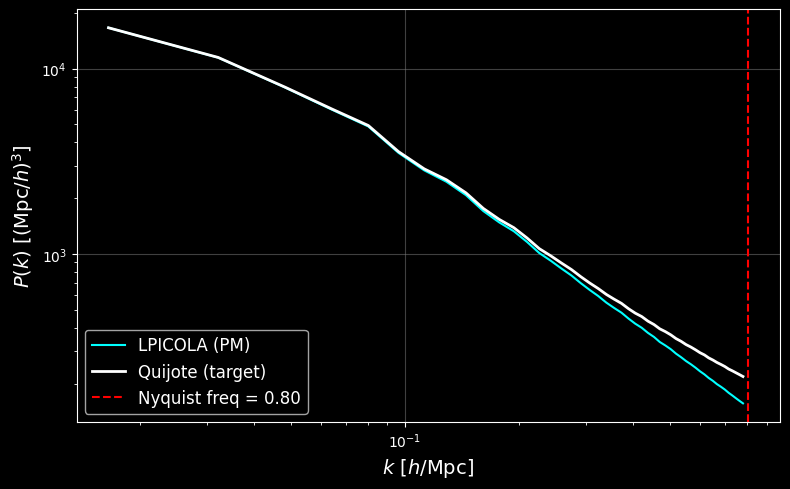

In [13]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(k_pm, Pk_pm, label="LPICOLA (PM)", color="cyan")
ax1.plot(k_nb, Pk_nb, label="Quijote (target)", color="white", lw=2)
ax1.axvline(kNyquist, color='r', ls='--', label='Nyquist freq = %.2f' % kNyquist)
ax1.legend(fontsize=12)
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=14)
ax1.set_ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$", fontsize=14)
ax1.grid(color="grey", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "initial_power_spectra.pdf"), bbox_inches="tight")


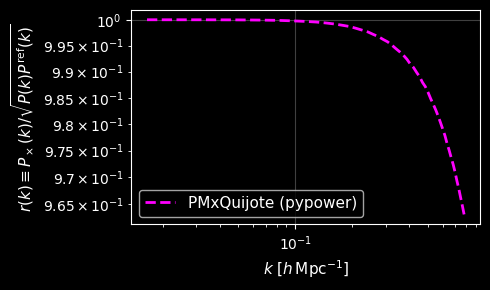

In [14]:
nbint = np.interp(k_X, k_nb_raw, Pk_nb_raw)
pmint = np.interp(k_X, k_pm_raw, Pk_pm_raw)

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(k_X, Pk_X / np.sqrt(nbint * pmint), '--', color="magenta", lw=2, label='PMxQuijote (pypower)')
ax.set_xscale("log"); ax.set_yscale("log")
ax.legend(fontsize=11)
ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=11)
ax.set_ylabel(r"$r(k) \equiv P_\times(k)/\sqrt{P(k)P^{\mathrm{ref}}(k)}$", fontsize=11)
ax.grid(color="gray", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "crosscorr_pm_nbody.pdf"), bbox_inches="tight")


# 2) Dark Matter particles - uncorrelated case

The perturbation field $\phi$ is statistically independent of $\Delta$, characterized by its
own power spectrum $Q(k)$:
$$
\langle\phi_\mathbf{q}\phi_{\mathbf{q}'}^*\rangle = \delta_D(\mathbf{q},\mathbf{q}')\frac{Q(q)}{V}.
$$

Taking the expectation over $\phi$ and then over $\Delta$ (full derivation: section 3.2.1 of
the notes) gives the target equation, linear in $Q$:
$$
V\langle\langle|\Delta'_\mathbf{k}|^2\rangle_\phi\rangle_\Delta \approx P(k) + k^4Q(k) + J_1(k) - J_2(k),
$$
with the sum-to-integral conversion $\sum_\mathbf{q}F(\mathbf{q})\to\frac{V}{(2\pi)^3}\int F\,d^3q$
(geometric, independent of the Fourier convention) giving
$$
J_1(k) = \frac{k^2}{(2\pi)^2}\int_0^{q_{\max}} q'^4Q(q')\left[\int_{-1}^1 P\big(\sqrt{k^2+q'^2-2kq'z}\big)z^2dz\right]dq',
\qquad
J_2(k) = \frac{2k^2P(k)}{3(2\pi)^2}\int_0^{q_{\max}} q'^4Q(q')\,dq'.
$$
($J_2$ shown here already includes the factor-of-2 fix discussed in the intro.)


## 2-1) Q computations


In [15]:
def build_Q_matrix(k, Pk, n_y=201):
    '''
    Build N such that P_target - P = N @ Q (uncorrelated-perturbation system),
    and N1, N2 such that:
        J1(k) = N1 @ Q   (cross term,  ~ P(|k-q|))
        J2(k) = N2 @ Q   (self term,   ~ P(k), factor-of-2 corrected -- see intro)
        N = diag(k**4) + N1 - N2

    I(k,q) = integral_{-1}^{1} y^2 * P(sqrt(k^2+q^2-2kqy)) dy

    Parameters
    ----------
    k    : (n_k,) array - k-bin centers [h/Mpc], used both as target k and as q
    Pk   : (n_k,) array - P(k) at those bins
    n_y  : int          - number of y=cos(theta) samples for the inner integral
    '''
    n_k = len(k)
    P_interp = interp1d(k, Pk, kind="linear", bounds_error=False,
                         fill_value=(Pk[0], Pk[-1]))
    y = np.linspace(-1, 1, n_y)

    I_mat = np.zeros((n_k, n_k))
    for i, ki in enumerate(k):
        for j, qj in enumerate(k):
            kq = np.sqrt(np.clip(ki**2 + qj**2 - 2*ki*qj*y, 0, None))
            I_mat[i, j] = _trapz(y**2 * P_interp(kq), y)

    dk = np.empty(n_k)
    dk[1:-1] = (k[2:] - k[:-2]) / 2
    dk[0] = (k[1] - k[0]) / 2
    dk[-1] = (k[-1] - k[-2]) / 2

    prefac = (k[:, None]**2 / (2*np.pi)**2) * (k[None, :]**4) * dk[None, :]
    N1 = prefac * I_mat                  # J1(k) = N1 @ Q
    N2 = prefac * (Pk[:, None] * 2. / 3.)  # J2(k) = N2 @ Q  (2026/06/29: factor-of-2 fix applied)
    N = np.diag(k**4) + N1 - N2
    return N, N1, N2


Negative Q(k) bins: 0 / 48 (clipped to zero before generating phi)


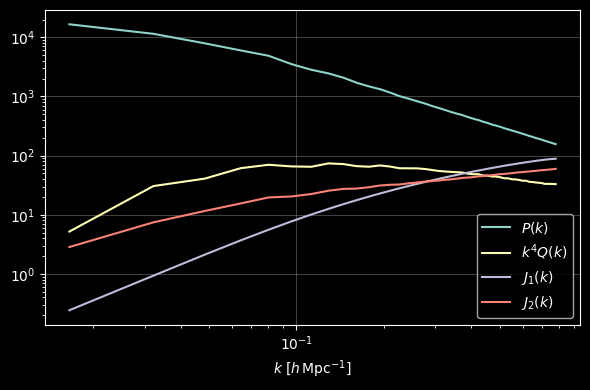

In [16]:
N, N1, N2 = build_Q_matrix(k_pm, Pk_pm)
dP = Pk_nb - Pk_pm
Q_sol = np.linalg.solve(N, dP)

J1 = N1 @ Q_sol
J2 = N2 @ Q_sol

print("Negative Q(k) bins: %d / %d (clipped to zero before generating phi)"
      % ((Q_sol < 0).sum(), len(Q_sol)))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_pm, Pk_pm, label=r"$P(k)$")
ax.plot(k_pm, k_pm**4 * Q_sol, label=r"$k^4Q(k)$")
ax.plot(k_pm, J1, label=r"$J_1(k)$")
ax.plot(k_pm, J2, label=r"$J_2(k)$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
ax.legend()
ax.grid(color= "grey", alpha = 0.5)
plt.tight_layout()


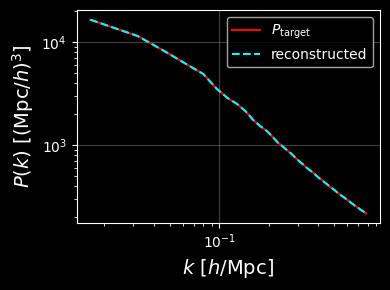

In [17]:
plt.figure(figsize = (4,3))
plt.loglog(k_nb, Pk_nb, color="red", label=r"$P_{\mathrm{target}}$")
plt.loglog(k_pm, Pk_pm + k_pm**4*Q_sol + J1 - J2, color="cyan", ls="--", label=r"reconstructed")
plt.legend()
plt.xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=14)
plt.ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$", fontsize=14)
plt.grid(color="grey", alpha=0.5)
plt.tight_layout()


## 2-2) Move particles with Q

Everything from "solve $Q$" through "displace the particles" is wrapped into a single
function, `correct_particles_with_Q`, taking the reference power spectrum (with its k-bins)
and the snapshot positions to correct as its main inputs. It measures the snapshot's own
$P(k)$ internally (via `measure_power_pypower`), so the caller only needs to supply the
target.

`zero_above_kmax` (default `True`) is the explicit, flagged version of the existing
"truncate Q above $k_\mathrm{Nyquist}$" behaviour: grid points in the 3D $|\mathbf{k}|$ cube
beyond the highest $k$-bin we actually solved $Q$ at get zero weight rather than an
extrapolated one, since $Q(k)$ was never solved out there. A diagnostic print reports how
many grid points (and what fraction of $k$-space) that affects each run.


In [18]:
def get_phi_and_accel_Q(Q_sol, k, grid, BoxSize, seed=None, n_threads=1,
                          zero_above_kmax=True, verbose=True):
    '''White-noise realization of phi(x) from the solved Q(k), and its gradient
    (the displacement-field acceleration), via pyfftw -- no Pylians.'''
    kx_v, ky_v, kz_v, k_radius = fourier_shells_k(grid, BoxSize, fshift=True)

    prec_in, prec_out = "complex64", "complex64"
    rng = np.random.default_rng(seed)
    white_noise = rng.normal(0., 1., size=(grid, grid, grid)).astype(prec_in)

    a_in = pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
    a_out = pyfftw.empty_aligned((grid, grid, grid), dtype='complex64')
    fftw_plan = pyfftw.FFTW(a_in, a_out, axes=(0, 1, 2), flags=('FFTW_ESTIMATE',),
                              direction='FFTW_FORWARD', threads=n_threads)
    a_in[:] = white_noise
    white_noise_fourier_shift = np.fft.fftshift(fftw_plan(a_in, a_out), axes=(0, 1, 2))

    # Delta_V = (BoxSize/grid)**3 is the cell volume: it converts "variance per discrete
    # grid cell" (what white noise gives you) into "power per unit physical volume"
    # (what Q(k) means).
    cell_volume = (BoxSize / grid)**3
    Q_safe = np.clip(Q_sol, 0., None)
    weights1D = np.sqrt(Q_safe / cell_volume)

    weights_grid = np.empty(white_noise_fourier_shift.shape)
    weights_grid, n_zeroed = fill_fourier_grid(weights_grid, k_radius, k, weights1D,
                                                 zero_above_kmax=zero_above_kmax)
    if verbose:
        frac = n_zeroed / k_radius.size
        print(f"  fill_fourier_grid: zero_above_kmax={zero_above_kmax} -> "
              f"{n_zeroed}/{k_radius.size} grid points ({frac:.1%}) beyond "
              f"k_max={k[-1]:.4f} h/Mpc set to zero weight.")

    phi_k_Q = weights_grid * white_noise_fourier_shift

    grad_x_fourier = 1.0j * kx_v[:, None, None] * phi_k_Q
    grad_y_fourier = 1.0j * ky_v[None, :, None] * phi_k_Q
    grad_z_fourier = 1.0j * kz_v[None, None, :] * phi_k_Q

    # Adding output phi in real space for random set of phases
    arr_in = pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
    arr_out = pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
    plan = pyfftw.FFTW(arr_in, arr_out, axes=(0, 1, 2), flags=('FFTW_ESTIMATE',),
                            direction='FFTW_BACKWARD', threads=n_threads)
    arr_in[:] = phi_k_Q.astype(prec_out)
    phi_r_Q = plan(np.fft.ifftshift(arr_in), arr_out).real

    accel = []
    for grad_fourier in (grad_x_fourier, grad_y_fourier, grad_z_fourier):
        arr_in = pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
        arr_out = pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
        plan = pyfftw.FFTW(arr_in, arr_out, axes=(0, 1, 2), flags=('FFTW_ESTIMATE',),
                            direction='FFTW_BACKWARD', threads=n_threads)
        arr_in[:] = grad_fourier.astype(prec_out)
        accel.append(plan(np.fft.ifftshift(arr_in), arr_out).real)

    return phi_k_Q, phi_r_Q , accel, n_zeroed


def correct_particles_with_Q(positions, BoxSize, grid,k_before, Pk_before, k_ref, Pk_ref,
                               measure_power_func, n_y=201, threshold = None,seed=None,
                               n_threads=None, zero_above_kmax=True,
                               remeasure=True, verbose=True):
    '''
    Move `positions` (a fast/approximate point set) so its power spectrum better
    matches the reference (k_ref, Pk_ref), via x' = x + grad(phi(x)) with phi drawn
    from the solved Q(k).

    Parameters
    ----------
    positions : (N, 3) array, particle positions of the snapshot to correct
    BoxSize, grid : box size and mesh resolution, used for both the P(k)
        measurement and the phi realization
    k_ref, Pk_ref : reference/target power spectrum to match, with its k-bins
    measure_power_func : callable(positions, BoxSize, grid) -> (k, Pk), e.g.
        a `measure_power_pypower` partial -- injected so this function has no
        hard pypower dependency and stays unit-testable on its own
    n_threads : pyfftw thread count for the phi/gradient FFTs; defaults to
        detect_compute_resources()['cpu_count']
    zero_above_kmax : bool, default True -- see markdown above

    Returns
    -------
    dict with: positions_corrected, Q, Q_clipped, k, N, N1, N2,
               Pk_before, n_zeroed_above_kmax, (k_after, Pk_after if remeasure)
    '''
    if n_threads is None:
        n_threads = detect_compute_resources()['cpu_count'] or 1

    #k_before, Pk_before = measure_power_func(positions, BoxSize, grid)

    Pk_ref_i = np.interp(k_before, k_ref, Pk_ref)
    N, N1, N2 = build_Q_matrix(k_before, Pk_before, n_y=n_y)
    Q_sol = np.linalg.solve(N, Pk_ref_i - Pk_before)
    Q_clipped = np.clip(Q_sol, 0., None)

    phi_k, phi_r, accel, n_zeroed = get_phi_and_accel_Q(
        Q_sol, k_before, grid, BoxSize, seed=seed, n_threads=n_threads,
        zero_above_kmax=zero_above_kmax, verbose=verbose)

    cell = BoxSize / grid
    length_grid = np.arange(0., BoxSize, cell)

    mag = np.sqrt(accel[0]**2 + accel[1]**2 + accel[2]**2)
    cell = BoxSize / grid
    print(f"Displacements > 1*cell:  {(mag > cell).mean():.3%}")
    print(f"Displacements > 2*cell:  {(mag > 2*cell).mean():.3%}")
    print(f"Displacements > BoxSize: {(mag > BoxSize).mean():.3%}")
    print(f"Max displacement: {mag.max():.4g} Mpc/h  (BoxSize = {BoxSize:.1f})")
    
    pos_corrected = np.empty(positions.shape, dtype="float32")
    pos_corrected, *_ = displace_positions_interp(
        positions.astype("float32"), pos_corrected,
        accel[0].astype("float32"), accel[1].astype("float32"), accel[2].astype("float32"),
        length_grid, length_grid, length_grid, BoxSize, threshold=threshold) # threshold = cell was previous behavior

    out = dict(positions_corrected=pos_corrected, Q=Q_sol, Q_clipped=Q_clipped,
               k=k_before, N=N, N1=N1, N2=N2, Pk_before=Pk_before,
               n_zeroed_above_kmax=n_zeroed, phi_k = phi_k, phi_r = phi_r)

    if remeasure:
        k_after, Pk_after = measure_power_func(pos_corrected, BoxSize, grid)
        out['k_after'], out['Pk_after'] = k_after, Pk_after

    return out


In [19]:
measure_power_func = lambda pos, B, g: measure_power_pypower(pos, B, g, kedges, ells=ells)

result_Q = correct_particles_with_Q(
    pos_pm, BoxSize, grid,k_pm, Pk_pm, k_nb, Pk_nb, measure_power_func,
    n_y=201, seed=seed, n_threads=resources['cpu_count'],
    zero_above_kmax=True, remeasure=True, verbose=True,
)
pos_corrected_Q = result_Q['positions_corrected']


  fill_fourier_grid: zero_above_kmax=True -> 8766155/16777216 grid points (52.3%) beyond k_max=0.7799 h/Mpc set to zero weight.
Displacements > 1*cell:  0.002%
Displacements > 2*cell:  0.000%
Displacements > BoxSize: 0.000%
Max displacement: 4.624 Mpc/h  (BoxSize = 1000.0)


1.382115115546474
(221,)
(256,)


[None, None]

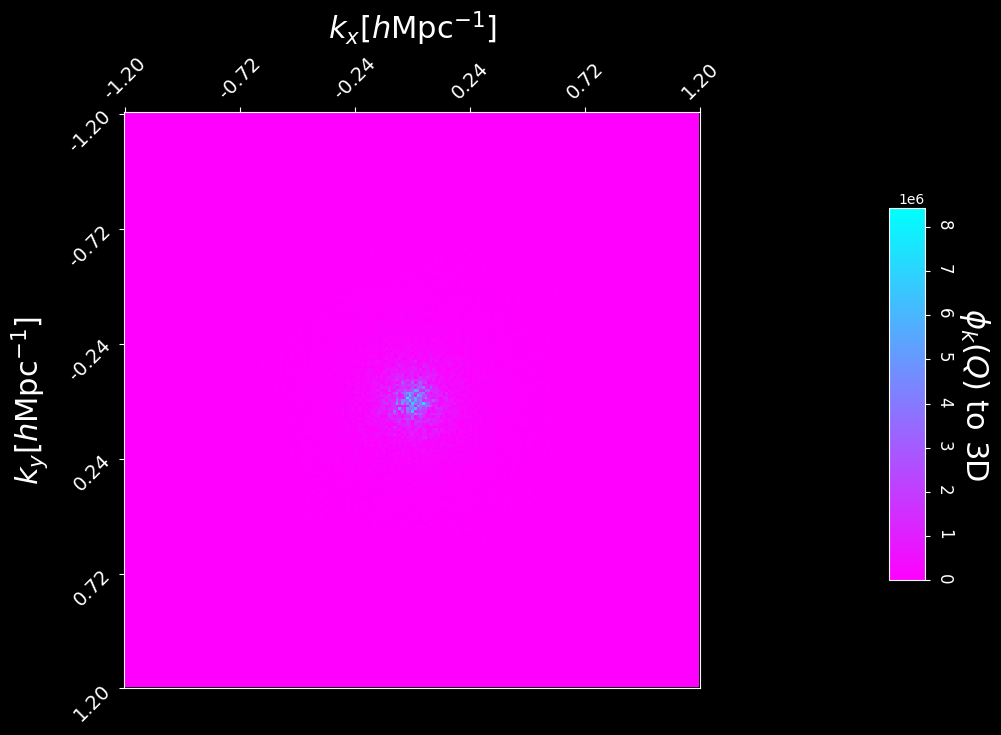

In [20]:
fig, ax1 = plt.subplots(figsize = (12, 6), nrows = 1, ncols = 1, 
                         sharex = False, sharey = False)
scale = 2*np.pi*grid/BoxSize  # k sampling rate
phi_k_Q = result_Q["phi_k"]
div_cmap = cm.cool_r
div_cmap.set_bad('black',1.)
origin = "upper"

#kpl = kx_v*np.sqrt(3)
freq = np.fft.fftshift(np.fft.fftfreq(grid))
kpl = scale * freq * np.sqrt(3)
print(kpl.max())
kmip = -1.2
kmap = -kmip

fshift = True
indp = np.where((kpl>=kmip)&(kpl<=kmap))[0]
print(indp.shape)
print(kpl.shape)
logscale = False
fact = 1.
#fact = np.sqrt(2)
indcut = 0 if not fshift else len(freq)//2 + 1
if logscale:
    im1 = ax1.matshow(abs(phi_k_Q[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      norm=LogNorm(vmin=1e-2, vmax=abs(phi_k_Q[:,:,indcut]).max()))

else:
    im1 = ax1.matshow(abs(phi_k_Q[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      vmin = abs(phi_k_Q[:,:,indcut]).min(), vmax = abs(phi_k_Q[:,:,indcut]).max())

# Colorbar setting
# can also use cbar = plt.colorbar(im1), and myCbar = cbar.ax
plt.subplots_adjust(bottom = 0.02, top = 0.98, right = 0.90, wspace = 0.45, hspace = 0.15)
myCbar = fig.add_axes(rect = [0.91, 0.2, 0.03, 0.62]) # left, bottom, width, height

cb = fig.colorbar(im1, cax=myCbar)
#cb.ax.minortickskN_off()
myCbar.tick_params(labelsize = 12, rotation = 270)
myCbar.set_ylabel(r"$\phi_k(Q)$" + " to 3D", fontsize = 22, rotation = 270)
myCbar.get_yaxis().labelpad = 28

fmtM = lambda x:"{:1.2f}".format(x)
labelM = np.linspace(0, kpl[indp].shape[0] - 1, 6, dtype = int)
labelH = np.linspace(0, kpl[indp].shape[0] - 1, 6, dtype = int)

ax1.set_xlabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_xticks(labelM)
ax1.set_yticks(labelM)
ax1.set_xticklabels([fmtM(j) for j in kpl[indp][labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_ticks_position('top')
ax1.set_yticklabels([fmtM(j) for j in kpl[indp][labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_label_position('top')
ax1.yaxis.set_label_position('left')
ax1.set(adjustable='box', aspect='equal')
#ax1.set_title("With Halo code (np.digitize)", fontsize = 20)


[None, None]

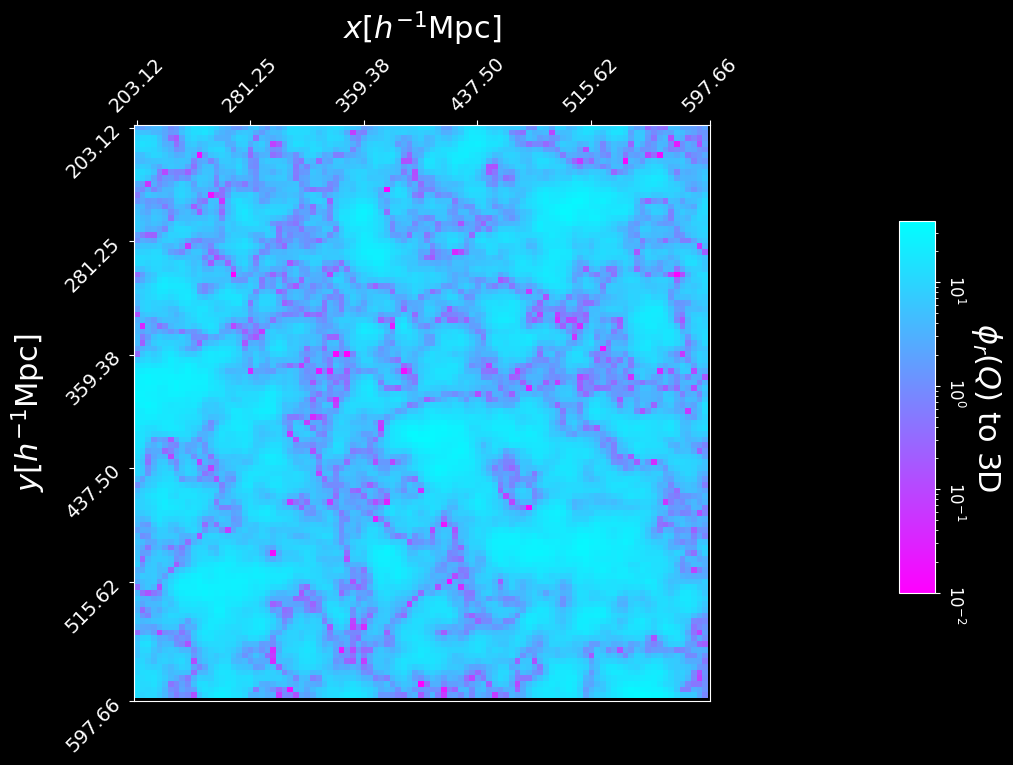

In [21]:
fig, ax1 = plt.subplots(figsize = (12, 6), nrows = 1, ncols = 1, 
                         sharex = False, sharey = False)
scale = 2*np.pi*grid/BoxSize  # k sampling rate
phi_r_Q = result_Q["phi_r"]
div_cmap = cm.cool_r
div_cmap.set_bad('black',1.)
origin = "upper"

fshift = True
logscale = True
fact = 1.
#fact = np.sqrt(2)

xmip = 200
xmap = 600
cell = BoxSize / grid
length_grid = np.arange(0., BoxSize, cell)
indcut = 0 if not fshift else len(length_grid)//2 + 1
fshift = True
indp = np.where((length_grid>=xmip)&(length_grid<=xmap))[0]


if logscale:
    im1 = ax1.matshow(abs(phi_r_Q[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      norm=LogNorm(vmin=1e-2, vmax=abs(phi_r_Q[:,:,indcut]).max()))

else:
    im1 = ax1.matshow(abs(phi_r_Q[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      vmin = abs(phi_r_Q[:,:,indcut]).min(), vmax = abs(phi_r_Q[:,:,indcut]).max())

# Colorbar setting
# can also use cbar = plt.colorbar(im1), and myCbar = cbar.ax
plt.subplots_adjust(bottom = 0.02, top = 0.98, right = 0.90, wspace = 0.45, hspace = 0.15)
myCbar = fig.add_axes(rect = [0.91, 0.2, 0.03, 0.62]) # left, bottom, width, height

cb = fig.colorbar(im1, cax=myCbar)
#cb.ax.minortickskN_off()
myCbar.tick_params(labelsize = 12, rotation = 270)
myCbar.set_ylabel(r"$\phi_r(Q)$" + " to 3D", fontsize = 22, rotation = 270)
myCbar.get_yaxis().labelpad = 28

fmtM = lambda x:"{:1.2f}".format(x)
labelM = np.linspace(0, length_grid[indp].shape[0] - 1, 6, dtype = int)
labelH = np.linspace(0, length_grid[indp].shape[0] - 1, 6, dtype = int)

ax1.set_xlabel(r"$x [h^{-1}\mathrm{Mpc}]$", fontsize = 22, labelpad = 10)
ax1.set_ylabel(r"$y [h^{-1}\mathrm{Mpc}]$", fontsize = 22, labelpad = 10)
ax1.set_xticks(labelM)
ax1.set_yticks(labelM)
ax1.set_xticklabels([fmtM(j) for j in length_grid[indp][labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_ticks_position('top')
ax1.set_yticklabels([fmtM(j) for j in length_grid[indp][labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_label_position('top')
ax1.yaxis.set_label_position('left')
ax1.set(adjustable='box', aspect='equal')
#ax1.set_title("With Halo code (np.digitize)", fontsize = 20)


Mean |displacement| = 1.066 Mpc/h  (grid cell = 3.906 Mpc/h)
Max  |displacement| = 250.8 Mpc/h  (grid cell = 3.906 Mpc/h)


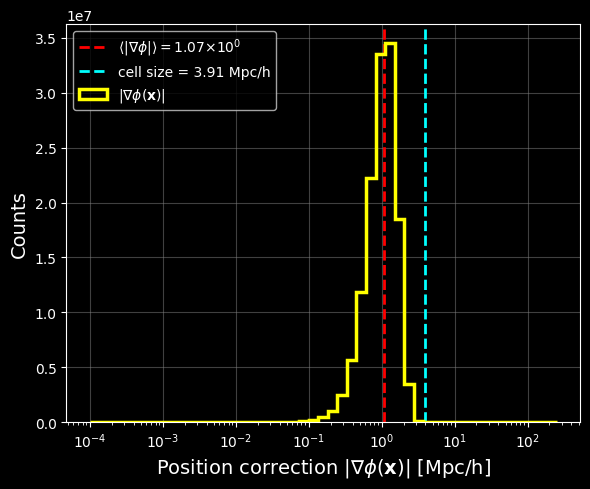

In [22]:
disp = pos_corrected_Q - pos_pm.astype('float32')
disp -= BoxSize * np.round(disp / BoxSize)   # minimum image convention
disp_mag = np.linalg.norm(disp, axis=1)

mean_disp = np.mean(disp_mag)

print("Mean |displacement| = %.4g Mpc/h  (grid cell = %.4g Mpc/h)" % (disp_mag.mean(), BoxSize/grid))
print("Max  |displacement| = %.4g Mpc/h  (grid cell = %.4g Mpc/h)" % (disp_mag.max(),  BoxSize/grid))
fig, ax = plt.subplots(figsize=(6, 5))
disp = pos_corrected_Q - pos_pm.astype('float32')
disp = disp - BoxSize * np.round(disp / BoxSize)   # <-- PBC-aware
disp_mag = np.linalg.norm(disp, axis=1)
bins = np.logspace(-4, np.log10(disp_mag.max() + 1e-12), 50)
ax.axvline(mean_disp, color="red", ls="--", lw=2, label=r"$\langle|\nabla\phi|\rangle = $" + sci_notation(mean_disp))
ax.axvline(BoxSize/grid, color="cyan", ls="--", lw=2, label="cell size = %.3g Mpc/h" % (BoxSize/grid))
ax.hist(disp_mag, bins=bins, histtype="step", lw=2.5, label=r"$|\nabla\phi(\mathbf{x})|$", color = "yellow")
ax.set_xscale("log")
ax.legend(fontsize=10)
ax.set_xlabel("Position correction " + r"$|\nabla\phi(\mathbf{x})|$" + " [Mpc/h]", fontsize=14)
ax.set_ylabel("Counts", fontsize=14)
ax.grid(color="gray", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "gradient_modulus_distribution_%s.pdf"%suffix), bbox_inches="tight")


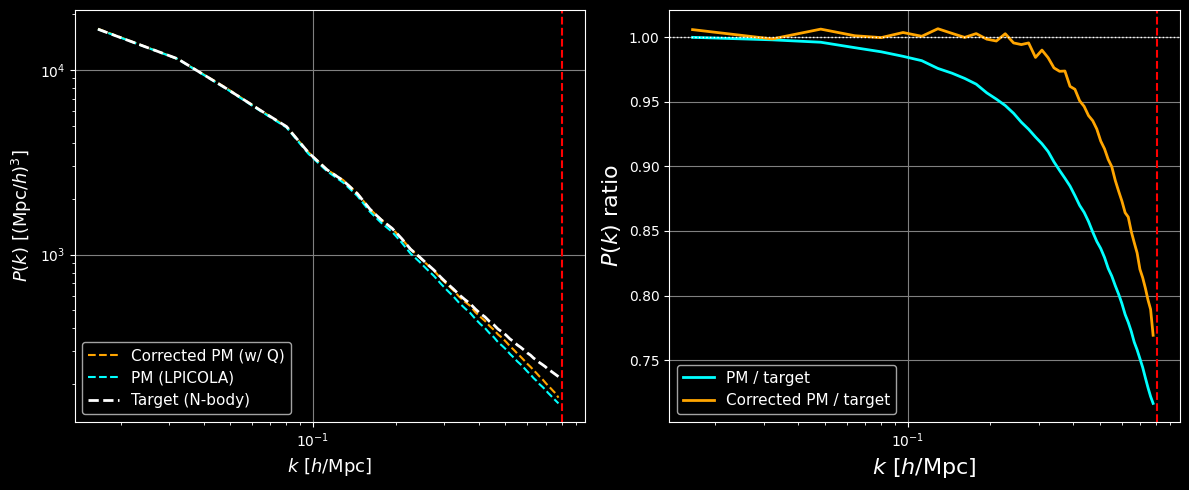

In [23]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
ax1, ax2 = axes
ax1.plot(result_Q['k_after'], result_Q['Pk_after'], label="Corrected PM (w/ Q)", color="orange", ls="--")
ax1.plot(k_pm, Pk_pm, label="PM (LPICOLA)", color="cyan", ls="--")
ax1.plot(k_nb, Pk_nb, label="Target (N-body)", color="white", lw=2, ls = "--")
ax1.axvline(kNyquist, color='r', ls='--')
ax1.legend(fontsize=11); ax1.grid(color="grey")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
ax1.set_ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$", fontsize=13)

ax2.plot(k_nb, Pk_pm/Pk_nb, label='PM / target', color="cyan", lw=2)
ax2.plot(result_Q['k_after'], result_Q['Pk_after']/np.interp(result_Q['k_after'], k_nb, Pk_nb),
         label='Corrected PM / target', color="orange", lw=2)
ax2.axhline(1.0, color="white", lw=1, ls=":")
ax2.axvline(kNyquist, color='r', ls='--')
ax2.legend(fontsize=11); ax2.grid(color="grey")
ax2.set_xscale("log")
ax2.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=16)
ax2.set_ylabel(r"$P(k)$ ratio", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "Pk_results_uncorrelated_%s.pdf"%suffix), bbox_inches="tight")


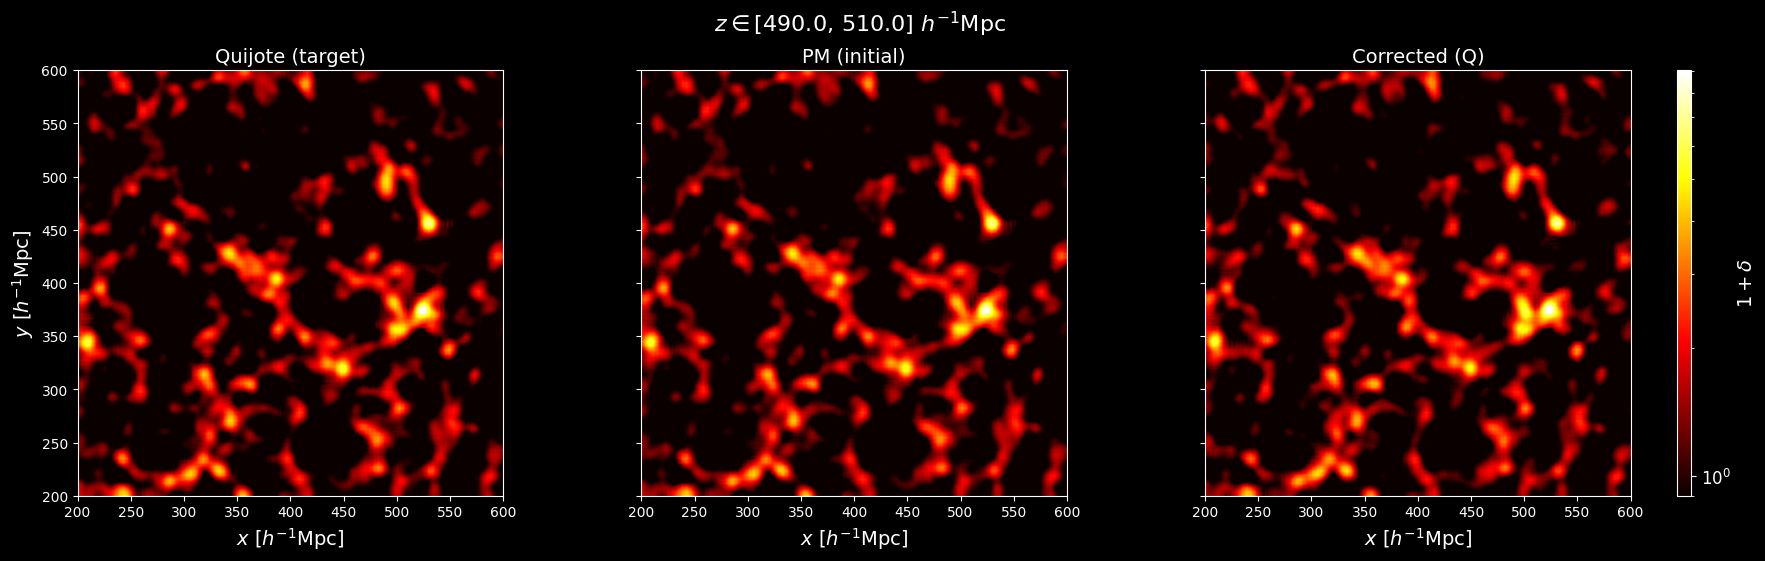

In [24]:
fig, axes = plot_density_slices(
    [pos_nb, pos_pm, pos_corrected_Q],
    ["Quijote (target)", "PM (initial)", "Corrected (Q)"],
    BoxSize, grid,
    x_min=xmip, x_max=xmap, y_min=xmip, y_max=xmap, z_min=490., z_max=510.,
    scale='log', colmap='hot', dmin=0.9, dmax=80,
    smooth_sigma=1.0,
    figroot=figroot, fname='dfield_slices_pm_nbody.pdf')

In [26]:
def detect_compute_resources():
    info = {'cpu_count': os.cpu_count()}
    for var in ("SLURM_CPUS_PER_TASK", "SLURM_NTASKS", "SLURM_JOB_CPUS_PER_NODE"):
        if var in os.environ:
            info[var] = os.environ[var]
    try:
        from mpi4py import MPI
        info['mpi4py_available'] = True
        info['mpi_world_size'] = MPI.COMM_WORLD.Get_size()
    except ImportError:
        info['mpi4py_available'] = False
        info['mpi_world_size'] = 1
    return info

resources = detect_compute_resources()
print(resources)


{'cpu_count': 128, 'SLURM_CPUS_PER_TASK': '35', 'SLURM_NTASKS': '1', 'SLURM_JOB_CPUS_PER_NODE': '35', 'mpi4py_available': True, 'mpi_world_size': 1}


In [27]:
mesh = CatalogMesh(data_positions=pos_pm, boxsize=BoxSize, nmesh=grid,
                   resampler='cic', interlacing=0, position_type='pos', dtype='f4')
delta_pm = np.array(mesh.to_mesh(compensate=False))
delta_pm = (delta_pm / delta_pm.mean() - 1.0).astype('float32')

print("one done")

mesh = CatalogMesh(data_positions=pos_nb, boxsize=BoxSize, nmesh=grid,
                   resampler='cic', interlacing=0, position_type='pos', dtype='f4')
delta_nb = np.array(mesh.to_mesh(compensate=False))
delta_nb = (delta_nb / delta_nb.mean() - 1.0).astype('float32')

print("two done")

mesh = CatalogMesh(data_positions=pos_corrected_Q, boxsize=BoxSize, nmesh=grid,
                   resampler='cic', interlacing=0, position_type='pos', dtype='f4')
delta_Q = np.array(mesh.to_mesh(compensate=False))
delta_Q = (delta_Q / delta_Q.mean() - 1.0).astype('float32')

one done
two done


In [28]:
n_threads = resources['cpu_count'] or 1

start = time.time()
base = pb.PolyBin3D(
    [BoxSize, BoxSize, BoxSize],
    [grid, grid, grid],
    boxcenter=[0, 0, 0],
    pixel_window='cic',
    backend='fftw',
    nthreads=n_threads,
    sightline='global')
print("PolyBin3D base init: %.1f s" % (time.time()-start))
print("k_fund = %.4f,  mean dk = %.4f" % (kFund, np.mean(np.diff(k_pm))))

down_factor = 1   # increase to speed up bispectrum (at the cost of k-resolution)
k_down = kedges[::down_factor]

bspec = pb.BSpec(base, k_down, lmax=0)
ks = bspec.get_ks()
k1_vals = np.unique(ks[0, :])
print("BSpec: %d valid triplets, %d unique k1 values" % (ks.shape[1], len(k1_vals)))


# Dimensions: [1.00e+03, 1.00e+03, 1.00e+03] Mpc/h
# Center: [0.00e+00, 0.00e+00, 0.00e+00] Mpc/h
# Line-of-sight: global
# Cartesian grid: [256, 256, 256]
# Fundamental frequency: [0.0063, 0.0063, 0.0063] h/Mpc
# Nyquist frequency: [0.804, 0.804, 0.804] h/Mpc
# Pixel window: cic
# Using FFTW backend
PolyBin3D base init: 6.4 s
k_fund = 0.0063,  mean dk = 0.0162

Binning: 48 bins in [0.006, 0.788] h/Mpc
l-max: 0
N_bins: 10100
Mask: constant
BSpec: 10100 valid triplets, 48 unique k1 values


In [29]:
recompbisp = False
bk_path = os.path.join("precomps", "bkQ_pm_bins%i_grid%i.npy" % (num_bins, grid))
ks_path = os.path.join("precomps", "bkQ_binspm_bins%i_grid%i.npy" % (num_bins, grid))

if os.path.exists(bk_path) and not recompbisp:
    print("Loading bispectrum from cache")
    bk_uncorr_pm = np.load(bk_path)
    ks_pm        = np.load(ks_path)
else:
    start = time.time()
    result_bk = bspec.Bk_ideal(delta_pm, discreteness_correction=False)
    bk_uncorr_pm = result_bk["b0"]
    ks_pm        = bspec.get_ks()
    np.save(bk_path, bk_uncorr_pm)
    np.save(ks_path, ks_pm)
    print("Bispectrum computed in %.1f s" % (time.time()-start))

print("bk shape:", bk_uncorr_pm.shape, "  ks shape:", ks_pm.shape)
k1_vals_pm = np.unique(ks_pm[0, :])


Loading bispectrum from cache
bk shape: (10100,)   ks shape: (3, 10100)


In [31]:
recompbisp = False
bk_path = os.path.join("precomps", "bkQ_nb_bins%i_grid%i.npy" % (num_bins, grid))
ks_path = os.path.join("precomps", "bkQ_binsnb_bins%i_grid%i.npy" % (num_bins, grid))

if os.path.exists(bk_path) and not recompbisp:
    print("Loading bispectrum from cache")
    bk_uncorr_nb = np.load(bk_path)
    ks_nb        = np.load(ks_path)
else:
    start = time.time()
    result_bk = bspec.Bk_ideal(delta_nb, discreteness_correction=False)
    bk_uncorr_nb = result_bk["b0"]
    ks_nb       = bspec.get_ks()
    np.save(bk_path, bk_uncorr_nb)
    np.save(ks_path, ks_nb)
    print("Bispectrum computed in %.1f s" % (time.time()-start))

print("bk shape:", bk_uncorr_nb.shape, "  ks shape:", ks_nb.shape)
k1_vals_nb = np.unique(ks_nb[0, :])


Loading bispectrum from cache
bk shape: (10100,)   ks shape: (3, 10100)


In [32]:
recompbisp = False
bk_path = os.path.join("precomps", "bkQ_Q_bins%i_grid%i.npy" % (num_bins, grid))
ks_path = os.path.join("precomps", "bkQ_binsQ_bins%i_grid%i.npy" % (num_bins, grid))

if os.path.exists(bk_path) and not recompbisp:
    print("Loading bispectrum from cache")
    bk_uncorr_Q = np.load(bk_path)
    ks_Q        = np.load(ks_path)
else:
    start = time.time()
    result_bk = bspec.Bk_ideal(delta_Q, discreteness_correction=False)
    bk_uncorr_Q = result_bk["b0"]
    ks_Q       = bspec.get_ks()
    np.save(bk_path, bk_uncorr_Q)
    np.save(ks_path, ks_Q)
    print("Bispectrum computed in %.1f s" % (time.time()-start))

print("bk shape:", bk_uncorr_Q.shape, "  ks shape:", ks_Q.shape)
k1_vals_Q = np.unique(ks_Q[0, :])



Bispectrum computed in 58.3 s
bk shape: (10100,)   ks shape: (3, 10100)


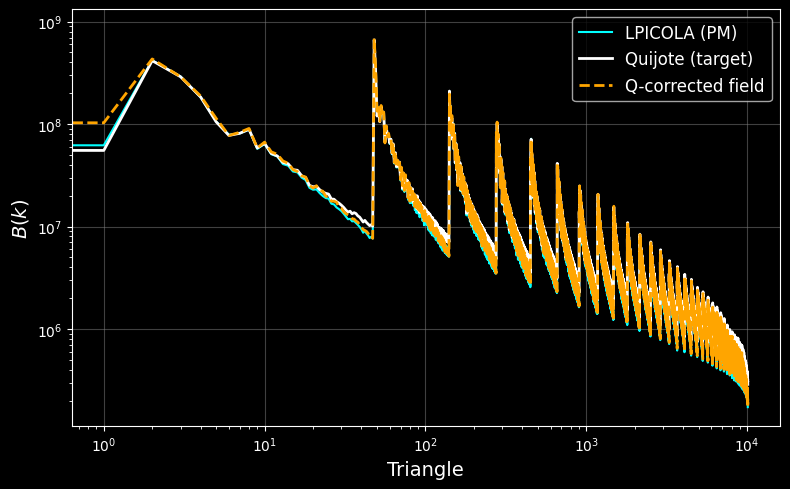

In [41]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(bk_uncorr_pm, label="LPICOLA (PM)", color="cyan")
ax1.plot(bk_uncorr_nb, label="Quijote (target)", color="white", lw=2)
ax1.plot( bk_uncorr_Q, label="Q-corrected field", color="orange", lw=2, ls = "--")
ax1.legend(fontsize=12)
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"Triangle", fontsize=14)
ax1.set_ylabel(r"$B(k)$", fontsize=14)
ax1.grid(color="grey", alpha=0.5)
plt.tight_layout()

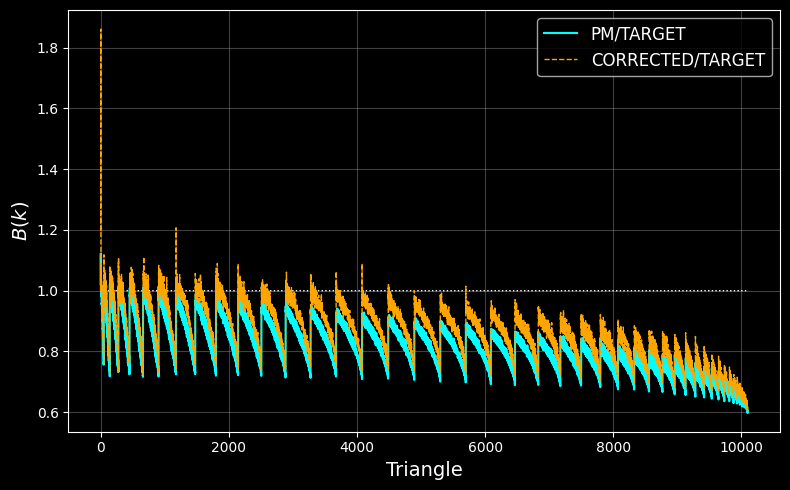

In [42]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(bk_uncorr_pm/bk_uncorr_nb, label="PM/TARGET", color="cyan")
ax1.plot(bk_uncorr_nb/bk_uncorr_nb, color="white", lw=1, ls ="dotted")
ax1.plot(bk_uncorr_Q/bk_uncorr_nb, label="CORRECTED/TARGET", color="orange", lw=1, ls = "--")
ax1.legend(fontsize=12)
ax1.set_xscale("linear"); ax1.set_yscale("linear")
ax1.set_xlabel(r"Triangle", fontsize=14)
ax1.set_ylabel(r"$B(k)$", fontsize=14)
ax1.grid(color="grey", alpha=0.5)
plt.tight_layout()

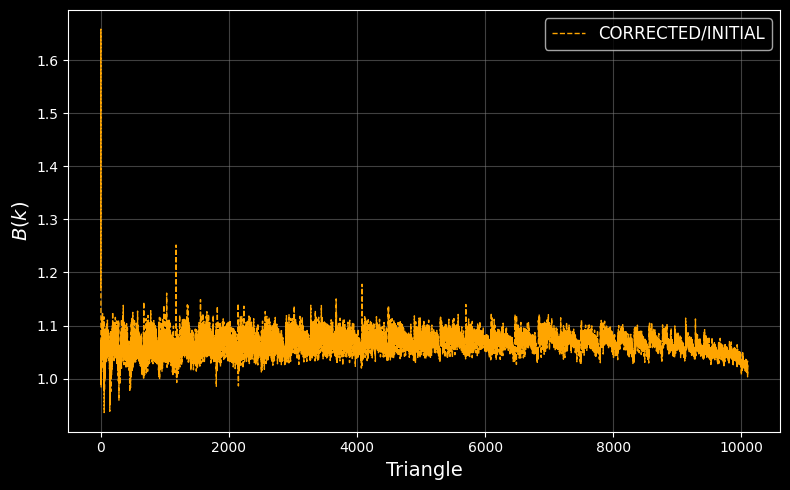

In [43]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(bk_uncorr_Q/bk_uncorr_pm, label="CORRECTED/INITIAL", color="orange", lw=1, ls = "--")
ax1.legend(fontsize=12)
ax1.set_xscale("linear"); ax1.set_yscale("linear")
ax1.set_xlabel(r"Triangle", fontsize=14)
ax1.set_ylabel(r"$B(k)$", fontsize=14)
ax1.grid(color="grey", alpha=0.5)
plt.tight_layout()

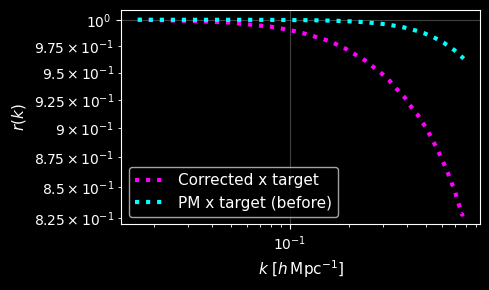

In [27]:
result_Xdisp = CatalogFFTPower(data_positions1=pos_nb, data_positions2=pos_corrected_Q,
                                boxsize=BoxSize, nmesh=grid, resampler=MAS.lower(),
                                edges=kedges, ells=ells, interlacing=interlacing_order,
                                position_type='pos', dtype='f4')
k_Xdisp, Pk_Xdisp = result_Xdisp.poles(ell=ells[0], return_k=True, complex=False)
mask_Xd = ~np.isnan(k_Xdisp) & ~np.isnan(Pk_Xdisp)
k_Xdisp, Pk_Xdisp = k_Xdisp[mask_Xd], Pk_Xdisp[mask_Xd]

dispint = np.interp(k_Xdisp, result_Q['k_after'], result_Q['Pk_after'])
nbint_d = np.interp(k_Xdisp, k_nb_raw, Pk_nb_raw)

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(k_Xdisp, Pk_Xdisp/np.sqrt(dispint*nbint_d), ':', color="magenta", lw=3, label='Corrected x target')
ax.plot(k_X, Pk_X/np.sqrt(nbint*pmint), ':', color="cyan", lw=3, label='PM x target (before)')
ax.set_xscale("log"); ax.set_yscale("log")
ax.legend(fontsize=11)
ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=11)
ax.set_ylabel(r"$r(k)$", fontsize=11)
ax.grid(color="gray", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "crosscorr_disp_nbody.pdf"), bbox_inches="tight")


## 2-3) Iterative Q corrections

In [41]:
def correct_particles_with_Q(positions, BoxSize, grid, k_ref, Pk_ref,
                               measure_power_func, n_y=201,threshold = None, seed=None,
                               n_threads=None, zero_above_kmax=True,
                               remeasure=True, verbose=True,
                               k_before=None, Pk_before=None):
    '''
    Move `positions` (a fast/approximate point set) so its power spectrum better
    matches the reference (k_ref, Pk_ref), via x' = x + grad(phi(x)) with phi drawn
    from the solved Q(k).

    k_before / Pk_before : optional pre-measured (k, P(k)) for `positions`. Pass
        these in to skip the internal measure_power_func call -- used by
        iterate_correction_with_Q below, where the previous iteration's
        "after" measurement is reused directly as this iteration's "before"
        spectrum, instead of re-measuring the same positions twice.

    Returns
    -------
    dict with: positions_corrected, Q, Q_clipped, k, N, N1, N2,
               Pk_before, n_zeroed_above_kmax, (k_after, Pk_after if remeasure)
    '''
    if n_threads is None:
        n_threads = detect_compute_resources()['cpu_count'] or 1

    if k_before is None or Pk_before is None:
        k_before, Pk_before = measure_power_func(positions, BoxSize, grid)
    elif verbose:
        print("  reusing previously-measured P(k) as this iteration's starting "
              "spectrum (skipping a redundant pypower call)")

    Pk_ref_i = np.interp(k_before, k_ref, Pk_ref)
    N, N1, N2 = build_Q_matrix(k_before, Pk_before, n_y=n_y)
    Q_sol = np.linalg.solve(N, Pk_ref_i - Pk_before)
    Q_clipped = np.clip(Q_sol, 0., None)

    phi_k, accel, n_zeroed = get_phi_and_accel_Q(
        Q_sol, k_before, grid, BoxSize, seed=seed, n_threads=n_threads,
        zero_above_kmax=zero_above_kmax, verbose=verbose)

    cell = BoxSize / grid
    length_grid = np.arange(0., BoxSize, cell)
    pos_corrected = np.empty(positions.shape, dtype="float32")

    mag = np.sqrt(accel[0]**2 + accel[1]**2 + accel[2]**2)
    cell = BoxSize / grid
    print(f"Displacements > 1*cell:  {(mag > cell).mean():.3%}")
    print(f"Displacements > 2*cell:  {(mag > 2*cell).mean():.3%}")
    print(f"Displacements > BoxSize: {(mag > BoxSize).mean():.3%}")
    print(f"Max displacement: {mag.max():.4g} Mpc/h  (BoxSize = {BoxSize:.1f})")
    
    pos_corrected, *_ = displace_positions_interp(
        positions.astype("float32"), pos_corrected,
        accel[0].astype("float32"), accel[1].astype("float32"), accel[2].astype("float32"),
        length_grid, length_grid, length_grid, BoxSize, threshold=threshold)

    out = dict(positions_corrected=pos_corrected, Q=Q_sol, Q_clipped=Q_clipped,
               k=k_before, N=N, N1=N1, N2=N2, Pk_before=Pk_before,
               n_zeroed_above_kmax=n_zeroed)

    if remeasure:
        k_after, Pk_after = measure_power_func(pos_corrected, BoxSize, grid)
        out['k_after'], out['Pk_after'] = k_after, Pk_after

    return out


def iterate_correction_with_Q(positions, BoxSize, grid, k_ref, Pk_ref, measure_power_func,
                                n_iterations=2, n_y=201,threshold = None, seed=None, n_threads=None,
                                zero_above_kmax=True, verbose=True):
    '''
    Repeatedly apply correct_particles_with_Q: each iteration's displaced particles
    become the next iteration's input positions, and each iteration's just-measured
    "after" P(k) becomes the next iteration's "before" P(k) -- no redundant pypower
    call. The target (k_ref, Pk_ref) stays fixed across iterations.

    Parameters
    ----------
    n_iterations : int, default 2
    seed : optional master seed; if given, a distinct (reproducible) sub-seed is
        drawn for each iteration's phi white-noise realization, so iterations
        don't reuse identical noise.

    Returns
    -------
    dict with:
      'positions'  : final corrected positions after n_iterations
      'history'    : list of length n_iterations of the per-iteration dicts
                      returned by correct_particles_with_Q (k, Pk_before, Q,
                      Q_clipped, N, N1, N2, n_zeroed_above_kmax, k_after, Pk_after)
    '''
    if seed is None:
        seeds = [None] * n_iterations
    else:
        rng = np.random.default_rng(seed)
        seeds = rng.integers(0, 2**31 - 1, size=n_iterations).tolist()

    history = []
    current_positions = positions
    k_before, Pk_before = None, None  # None on iteration 0 -> forces the one real measurement

    for it in range(n_iterations):
        if verbose:
            print(f"=== iteration {it + 1}/{n_iterations} ===")

        result = correct_particles_with_Q(
            current_positions, BoxSize, grid, k_ref, Pk_ref, measure_power_func,
            n_y=n_y, threshold = threshold,seed=seeds[it], n_threads=n_threads,
            zero_above_kmax=zero_above_kmax, remeasure=True, verbose=verbose,
            k_before=k_before, Pk_before=Pk_before,
        )
        history.append(result)

        # this iteration's displaced particles + their just-measured P(k)
        # become next iteration's starting point
        current_positions = result['positions_corrected']
        k_before, Pk_before = result['k_after'], result['Pk_after']

        if verbose:
            Pk_ref_i = np.interp(k_before, k_ref, Pk_ref)
            rel = np.mean(np.abs((Pk_before - Pk_ref_i) / Pk_ref_i))
            print(f"  mean relative |P - P_target|/P_target after this iteration: {rel:.4f}")

    return dict(positions=current_positions, history=history)

In [45]:
measure_power_func = lambda pos, B, g: measure_power_pypower(pos, B, g, kedges, ells=ells)

loop_result = iterate_correction_with_Q(
    pos_pm, BoxSize, grid, k_nb, Pk_nb, measure_power_func,
    n_iterations=4, n_y=201, seed=seed, n_threads=resources['cpu_count'],
    zero_above_kmax=True, verbose=True
)
pos_corrected_Q = loop_result['positions']  # final positions, n_iterations in

=== iteration 1/4 ===
  fill_fourier_grid: zero_above_kmax=True -> 70164747/134217728 grid points (52.3%) beyond k_max=1.5596 h/Mpc set to zero weight.
Displacements > 1*cell:  30.673%
Displacements > 2*cell:  0.239%
Displacements > BoxSize: 0.000%
Max displacement: 6.74 Mpc/h  (BoxSize = 1000.0)
  mean relative |P - P_target|/P_target after this iteration: 0.1499
=== iteration 2/4 ===
  reusing previously-measured P(k) as this iteration's starting spectrum (skipping a redundant pypower call)
  fill_fourier_grid: zero_above_kmax=True -> 70164747/134217728 grid points (52.3%) beyond k_max=1.5596 h/Mpc set to zero weight.
Displacements > 1*cell:  1.110%
Displacements > 2*cell:  0.000%
Displacements > BoxSize: 0.000%
Max displacement: 4.07 Mpc/h  (BoxSize = 1000.0)
  mean relative |P - P_target|/P_target after this iteration: 0.0954
=== iteration 3/4 ===
  reusing previously-measured P(k) as this iteration's starting spectrum (skipping a redundant pypower call)
  fill_fourier_grid: zero_a

In [46]:
def plot_iteration_history(history, k_pm, Pk_pm, k_target, Pk_target,
                             kNyquist=None, figroot=None, cmap=cm.viridis):
    '''
    Two-column diagnostic plot (P(k), and P(k)/P_target ratio) showing the
    initial PM spectrum, the target, and every iteration's corrected spectrum
    from iterate_correction_with_Q's `history` list.

    Parameters
    ----------
    history : list of dicts, as returned in loop_result['history'] from
        iterate_correction_with_Q -- each needs 'k_after' and 'Pk_after'
    k_pm, Pk_pm : the *initial*, uncorrected PM power spectrum (pre-loop)
    k_target, Pk_target : the reference/target power spectrum
    kNyquist : optional, draws a vertical reference line on both panels
    figroot : optional directory to save the figure pdf into
    cmap : colormap used to shade iterations from early (light) to late (dark)
    '''
    n_it = len(history)
    colors = cmap(np.linspace(0.25, 0.95, n_it))

    fig, axes = plt.subplots(ncols=2, figsize=(12, 5))
    ax1, ax2 = axes

    # --- left: P(k) ---
    ax1.plot(k_pm, Pk_pm, label="PM (initial)", color="darkblue", ls="--")
    for i, h in enumerate(history):
        ax1.plot(h['k_after'], h['Pk_after'], color=colors[i],
                  label=f"corrected, it. {i + 1}/{n_it}")
    ax1.plot(k_target, Pk_target, label="target", color="white", lw=2)
    if kNyquist is not None:
        ax1.axvline(kNyquist, color='r', ls='--', label='Nyquist freq = %.2f' % kNyquist)
    ax1.set_xscale("log"); ax1.set_yscale("log")
    ax1.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
    ax1.set_ylabel(r"$P(k)\ [(\mathrm{Mpc}/h)^3]$", fontsize=13)
    ax1.legend(fontsize=9); ax1.grid(color="grey", alpha=0.4)

    # --- right: ratio to target ---
    Pk_target_on_pm = np.interp(k_pm, k_target, Pk_target)
    ax2.plot(k_pm, Pk_pm / Pk_target_on_pm, label="PM (initial) / target",
              color="darkblue", ls="--")
    for i, h in enumerate(history):
        Pk_target_i = np.interp(h['k_after'], k_target, Pk_target)
        ax2.plot(h['k_after'], h['Pk_after'] / Pk_target_i, color=colors[i],
                  label=f"corrected, it. {i + 1}/{n_it} / target")
    ax2.axhline(1.0, color="white", lw=1, ls=":")
    if kNyquist is not None:
        ax2.axvline(kNyquist, color='r', ls='--')
    ax2.set_xscale("log")
    ax2.set_xlabel(r"$k\ [h/\mathrm{Mpc}]$", fontsize=13)
    ax2.set_ylabel(r"$P(k)$ ratio", fontsize=13)
    ax2.legend(fontsize=9); ax2.grid(color="grey", alpha=0.4)

    plt.tight_layout()
    if figroot is not None:
        os.makedirs(figroot, exist_ok=True)
        plt.savefig(os.path.join(figroot, "Pk_results_uncorrelated_iterations.pdf"), bbox_inches="tight")
    return fig, axes

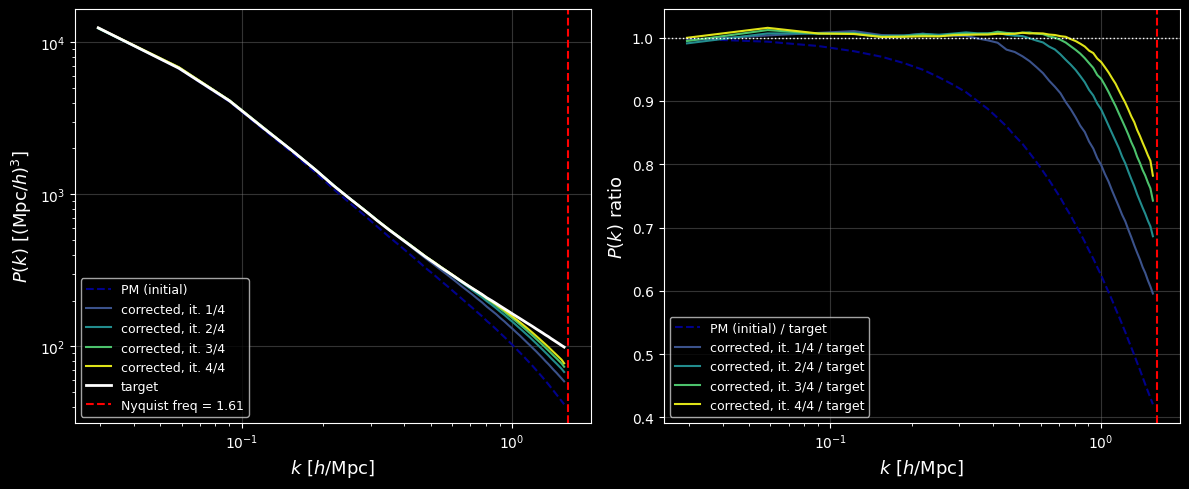

In [47]:
fig, axes = plot_iteration_history(
    loop_result['history'], k_pm, Pk_pm, k_nb, Pk_nb,
    kNyquist=kNyquist, figroot=figroot,
)

In [52]:
len(loop_result["history"])

4

In [54]:
loop_result["history"][-1].keys()

dict_keys(['positions_corrected', 'Q', 'Q_clipped', 'k', 'N', 'N1', 'N2', 'Pk_before', 'n_zeroed_above_kmax', 'k_after', 'Pk_after'])

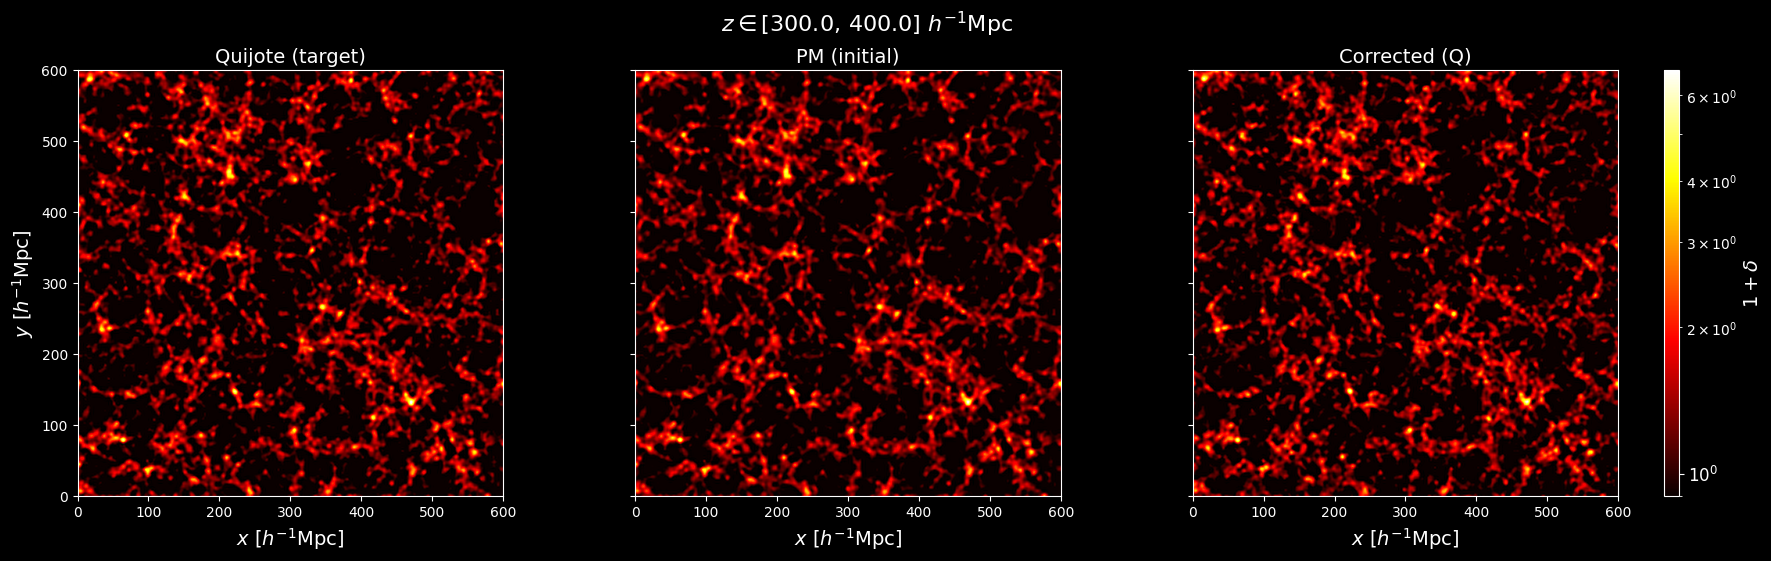

In [59]:
fig, axes = plot_density_slices(
    [pos_nb, pos_pm, loop_result["history"][-1]["positions_corrected"]],
    ["Quijote (target)", "PM (initial)", "Corrected (Q)"],
    BoxSize, grid,
    x_min=0., x_max=600., y_min=0., y_max=600., z_min=300., z_max=400.,
    scale='log', colmap='hot', dmin=0.9, dmax=80,
    smooth_sigma=1.0,
    figroot=figroot, fname='dfield_slices_pm_nbody.pdf')

In [65]:
def compute_cross_correlation_history(history, pos_ref, k_ref_raw, Pk_ref_raw,
                                        BoxSize, grid, kedges,
                                        pos_initial=None, resampler='cic',
                                        interlacing=2, dtype='f4', ells=(0,),
                                        verbose=True):
    '''
    Cross-correlation coefficient r(k) = P_x(k) / sqrt(P(k) * P_ref(k)) between
    the reference/target positions `pos_ref` and each iteration's corrected
    positions in `history` (loop_result['history'] from iterate_correction_with_Q).

    Uses remove_shotnoise=False for BOTH auto-spectra in the denominator --
    pypower only subtracts shot noise from auto-, not cross-, spectra by
    default, so pairing a shot-noise-subtracted auto with the cross term can
    push r(k) above 1.

    Parameters
    ----------
    history     : list of dicts, each with a 'positions_corrected' key
    pos_ref     : reference/target particle positions (e.g. pos_nb)
    k_ref_raw, Pk_ref_raw : pre-measured RAW (remove_shotnoise=False) auto
                  P(k) of pos_ref -- pass in what you already have from Setup
                  (k_nb_raw, Pk_nb_raw) instead of re-measuring it per call
    pos_initial : optional, the original *uncorrected* PM positions -- if
                  given, r(k) against them is computed too and stored first,
                  so the plot can show the before-any-correction baseline

    Returns
    -------
    list of dicts [{'k':..., 'r':..., 'label':...}, ...], in order
    (pos_initial first if given, then one entry per iteration)
    '''
    entries = []
    if pos_initial is not None:
        entries.append(('initial (uncorrected)', pos_initial))
    for i, h in enumerate(history):
        entries.append((f"it. {i + 1}/{len(history)}", h['positions_corrected']))

    cc_history = []
    for label, pos_i in entries:
        if verbose:
            print(f"  cross-correlating '{label}' ...")

        # raw (shot-noise-NOT-removed) auto P(k) of this entry's positions
        k_auto, Pk_auto_raw = measure_power_pypower(
            pos_i, BoxSize, grid, kedges, resampler=resampler,
            interlacing=interlacing, dtype=dtype, ells=ells, remove_shotnoise=False)

        result_X = CatalogFFTPower(data_positions1=pos_ref, data_positions2=pos_i,
                                    boxsize=BoxSize, nmesh=grid, resampler=resampler,
                                    edges=kedges, ells=ells, interlacing=interlacing,
                                    position_type='pos', dtype=dtype)
        k_X, Pk_X = result_X.poles(ell=ells[0], return_k=True, complex=False)
        mask = ~np.isnan(k_X) & ~np.isnan(Pk_X)
        k_X, Pk_X = k_X[mask], Pk_X[mask]

        Pk_ref_i = np.interp(k_X, k_ref_raw, Pk_ref_raw)
        Pk_auto_i = np.interp(k_X, k_auto, Pk_auto_raw)
        r = Pk_X / np.sqrt(Pk_ref_i * Pk_auto_i)

        cc_history.append(dict(k=k_X, r=r, label=label))

    return cc_history


def plot_cross_correlation_history(cc_history, kNyquist=None, figroot=None, cmap=cm.viridis):
    '''
    Plot r(k) for every entry in cc_history (from compute_cross_correlation_history).
    The 'initial (uncorrected)' entry, if present, is drawn as a dashed dark-blue
    baseline; iterations are shaded light -> dark by iteration number.
    '''
    n = len(cc_history)
    colors = cmap(np.linspace(0.15, 0.95, n))

    fig, ax = plt.subplots(figsize=(6, 4.5))
    for i, entry in enumerate(cc_history):
        is_initial = 'initial' in entry['label']
        style = '--' if is_initial else '-'
        color = 'darkblue' if is_initial else colors[i]
        ax.plot(entry['k'], entry['r'], style, color=color, lw=2, label=entry['label'])
    ax.axhline(1.0, color="white", lw=1, ls=":")
    if kNyquist is not None:
        ax.axvline(kNyquist, color='r', ls='--')
    ax.set_xscale("log")
    ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$", fontsize=12)
    ax.set_ylabel(r"$r(k) \equiv P_\times(k)/\sqrt{P(k)P^{\mathrm{ref}}(k)}$", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(color="gray", alpha=0.5)
    plt.tight_layout()
    if figroot is not None:
        os.makedirs(figroot, exist_ok=True)
        plt.savefig(os.path.join(figroot, "crosscorr_iterations.pdf"), bbox_inches="tight")
    return fig, ax

In [66]:
cc_history = compute_cross_correlation_history(
    loop_result['history'], pos_nb, k_nb_raw, Pk_nb_raw,
    BoxSize, grid, kedges, pos_initial=pos_pm,
)


  cross-correlating 'initial (uncorrected)' ...
  cross-correlating 'it. 1/3' ...
  cross-correlating 'it. 2/3' ...
  cross-correlating 'it. 3/3' ...


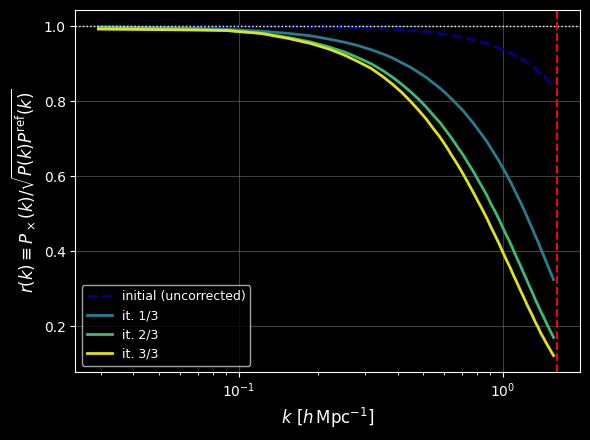

In [67]:
fig, ax = plot_cross_correlation_history(cc_history, kNyquist=kNyquist, figroot=figroot)

# Appendix: quick validation on a synthetic mock

A self-contained sanity check of `build_Q_matrix` / `get_phi_and_accel_Q` /
`correct_particles_with_Q` above, using a lognormal mock catalog with a known input $P(k)$
instead of real snapshots -- useful to confirm the pipeline behaves before pointing it at the
real PM/N-body snapshots. No pypower/Pylians/snapshot files needed here: P(k) is measured
with a plain CIC + FFT periodogram. Re-uses the exact same functions defined above (no
redefinition).


In [28]:
def cic_density_mock(positions, BoxSize, grid):
    N = positions.shape[0]
    cell = BoxSize / grid
    pos_cell = positions / cell
    i0 = np.floor(pos_cell).astype(int)
    d = pos_cell - i0
    rho = np.zeros((grid, grid, grid))
    for dx in (0, 1):
        for dy in (0, 1):
            for dz in (0, 1):
                w = (d[:, 0] if dx else 1 - d[:, 0]) * \
                    (d[:, 1] if dy else 1 - d[:, 1]) * \
                    (d[:, 2] if dz else 1 - d[:, 2])
                ix = (i0[:, 0] + dx) % grid
                iy = (i0[:, 1] + dy) % grid
                iz = (i0[:, 2] + dz) % grid
                np.add.at(rho, (ix, iy, iz), w)
    nbar = N / grid**3
    return rho / nbar - 1.0


def measure_power_direct_mock(positions, BoxSize, grid, kbins):
    '''Plain CIC + FFT periodogram, standing in for pypower in this appendix only.'''
    delta = cic_density_mock(positions, BoxSize, grid)
    V = BoxSize**3
    dV = (BoxSize / grid)**3
    delta_k = np.fft.fftn(delta) * dV / V
    power_field = V * np.abs(delta_k)**2

    kf = 2 * np.pi / BoxSize
    k1d = np.fft.fftfreq(grid, d=1.0/grid) * kf
    KX, KY, KZ = np.meshgrid(k1d, k1d, k1d, indexing='ij')
    kmag = np.sqrt(KX**2 + KY**2 + KZ**2).ravel()
    pf = power_field.ravel()

    idx = np.digitize(kmag, kbins)
    k_out, P_out = [], []
    for b in range(1, len(kbins)):
        sel = idx == b
        if sel.sum() == 0:
            continue
        k_out.append(kmag[sel].mean())
        P_out.append(pf[sel].mean())
    k_out, P_out = np.array(k_out), np.array(P_out)
    P_out -= V / positions.shape[0]  # shot noise
    return k_out, P_out


def lognormal_mock(Pk_func, BoxSize, grid, nbar, seed=None):
    rng = np.random.default_rng(seed)
    w = rng.standard_normal((grid, grid, grid))
    w_k = np.fft.fftn(w)
    kf = 2 * np.pi / BoxSize
    k1d = np.fft.fftfreq(grid, d=1.0/grid) * kf
    KX, KY, KZ = np.meshgrid(k1d, k1d, k1d, indexing='ij')
    kmag = np.sqrt(KX**2 + KY**2 + KZ**2)
    dV = (BoxSize / grid)**3
    Pk = Pk_func(kmag.ravel()).reshape(kmag.shape)
    Pk[kmag == 0] = 0.0
    A = np.sqrt(np.clip(Pk, 0, None) / dV)
    delta_g = np.fft.ifftn(A * w_k).real
    sigma2 = delta_g.var()
    delta_ln = np.exp(delta_g - sigma2/2.0) - 1.0
    lam = np.clip(nbar * (1 + delta_ln) * dV, 0, None)
    counts = rng.poisson(lam)
    cell = BoxSize / grid
    idx = np.argwhere(counts > 0)
    base = np.repeat(idx, counts[counts > 0], axis=0).astype(float)
    jitter = rng.uniform(0, 1, size=base.shape)
    return ((base + jitter) * cell) % BoxSize


In [38]:
BoxSize_mock, grid_mock, nbar_mock = 200.0, 32, 0.02
kbins_mock = np.linspace(0.05, 0.9, 14)

def P_PM_mock(k):
    return 1.2e4 * (k/0.15)**-1.6 / (1 + (k/0.15)**2)

def P_target_mock(k):
    return 2.0e4 * (k/0.18)**-1.5 / (1 + (k/0.18)**2)

pos_pm_mock = lognormal_mock(P_PM_mock, BoxSize_mock, grid_mock, nbar_mock, seed=42)
print("Mock PM particle count:", pos_pm_mock.shape[0])

measure_power_func_mock = lambda pos, B, g: measure_power_direct_mock(pos, B, g, kbins_mock)
k_ref_mock, _ = measure_power_func_mock(pos_pm_mock, BoxSize_mock, grid_mock)
Pk_ref_mock = P_target_mock(k_ref_mock)

result_mock = correct_particles_with_Q(
    pos_pm_mock, BoxSize_mock, grid_mock, k_ref_mock, Pk_ref_mock, measure_power_func_mock,
    n_y=20, seed=7, n_threads=2, zero_above_kmax=True, remeasure=True, verbose=True,
)

resid = result_mock['N'] @ result_mock['Q'] - (np.interp(result_mock['k'], k_ref_mock, Pk_ref_mock) - result_mock['Pk_before'])
print("Linear-system bookkeeping check, max |residual|:", np.max(np.abs(resid)))
print("Negative-Q bins:", (result_mock['Q'] < 0).sum(), "/", len(result_mock['Q']))


/tmp/ipykernel_663398/1355702807.py:5: RuntimeWarning: divide by zero encountered in power
  return 1.2e4 * (k/0.15)**-1.6 / (1 + (k/0.15)**2)


Mock PM particle count: 177484
  fill_fourier_grid: zero_above_kmax=True -> 7/32768 grid points (0.0%) beyond k_max=0.8408 h/Mpc set to zero weight.
Linear-system bookkeeping check, max |residual|: 1.3642420526593924e-12
Negative-Q bins: 5 / 13


Linear-system bookkeeping check, max |residual|: 9.094947017729282e-13
Negative-Q bins: 5 / 13


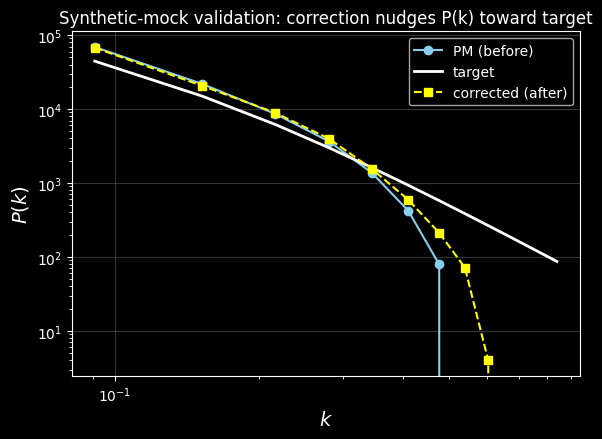

In [39]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(result_mock['k'], result_mock['Pk_before'], 'o-', label='PM (before)', color='skyblue')
ax.plot(k_ref_mock, Pk_ref_mock, '-', label='target', color='white', lw=2)
ax.plot(result_mock['k_after'], result_mock['Pk_after'], 's--', label='corrected (after)', color='yellow')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$k$', fontsize = 14); ax.set_ylabel(r'$P(k)$', fontsize = 14)
ax.legend(fontsize=10)
ax.grid(color='grey', alpha=0.4)
ax.set_title('Synthetic-mock validation: correction nudges P(k) toward target')
plt.tight_layout()
